# Optimización multi-activo con cripto: capítulo 2

## Robustez, costes y evidencia confirmatoria sobre el baseline de Mínima Varianza

*Capítulo 2 — qué parte del baseline sobrevive a perturbaciones razonables del diseño.*

---

### Resumen

El baseline de Mínima Varianza (MV) caracterizado en el Capítulo 1 muestra un perfil defensivo y un uso muy moderado del *sleeve* cripto. Antes de añadir complejidad metodológica conviene preguntarse algo más básico: **¿qué de ese resultado es atribuible al diseño y qué se mueve cuando perturbamos el diseño?** Este capítulo explora esa pregunta a lo largo de cuatro dimensiones, una a la vez:

- ventana de estimación (*lookback*) de 126 / 252 / 504 días,
- techo agregado de cripto (0% / 10% / 20% / 25%),
- frecuencia de rebalanceo (mensual vs trimestral),
- estimador de la matriz de covarianzas (muestral vs Ledoit-Wolf).

Cada variante se evalúa **gross** y **net** de un *wedge* de costes (0 / 10 / 25 / 50 bps aplicado al *turnover* one-way), y se contrasta con un control sin cripto bajo idéntica mecánica para aislar el papel del *sleeve*. La lectura primaria se hace sobre la muestra alineada por familia (`common_family`) para evitar contaminar comparaciones con ventanas OOS de longitud distinta. Sobre esa capa descriptiva se monta una capa confirmatoria deliberadamente ligera: intervalos de bootstrap por bloques (Politis y Romano, 1994) sobre un conjunto **preregistrado** de contrastes en diferencias de Sharpe. No se reclama inferencia más allá de ese subconjunto.

### Pregunta de investigación

> ¿Las propiedades descriptivas del baseline —perfil defensivo, uso bajo y estable de cripto, *turnover* plausible— sobreviven a perturbaciones razonables del diseño y al *wedge* de costes, y los contrastes preregistrados de Sharpe son detectables bajo bootstrap?

### Qué hace y qué no hace este notebook

| Hace | No hace |
|---|---|
| Mapea la sensibilidad de métricas, pesos y *turnover* a cada dimensión. | Re-correr el optimizador. |
| Cuantifica el *cost drag* gross-vs-net y el orden por familia. | Modelar *slippage*, impacto o ejecuciones parciales. |
| Compara baseline vs control sin cripto bajo idéntica mecánica. | Identificar la contribución causal del *sleeve* cripto. |
| Lee intervalos preregistrados de bootstrap para diferencias de Sharpe. | Extender la inferencia más allá del conjunto preregistrado. |
| Diagnostica concentración y estabilidad de pesos entre especificaciones. | Descomponer riesgo en contribución marginal a la varianza. |

El notebook **no implementa** ninguna especificación nueva. Carga artefactos precomputados por `scripts/run_robustness.py` y `scripts/run_statistical_confidence.py`, ubicados en `data/processed/robustness/`, y aplica transformaciones y lectura económica.


### Anclas en la literatura

El diseño se apoya en cuatro hechos estilizados de la literatura de construcción de carteras:

- **MV es sensible a los inputs, pero las restricciones regularizan.** Best y Grauer (1991) y Chopra y Ziemba (1993) documentan la sensibilidad de la MV no restringida; Jagannathan y Ma (2003) muestran que las restricciones de no-corto y los topes funcionan como *shrinkage* implícito y suelen mejorar el OOS. Las familias *crypto-cap* y *covariance-method* tocan directamente este canal.
- **El error de estimación domina el bajo rendimiento OOS.** Ledoit y Wolf (2003, 2004) proponen *shrinkage* lineal de la covarianza muestral hacia un *target* estructurado; la familia *covariance-method* (sample vs Ledoit-Wolf) lee exactamente esa dimensión.
- **1/N es un benchmark difícil de batir.** DeMiguel, Garlappi y Uppal (2009) documentan que la diversificación naïve es difícil de superar OOS una vez se contabilizan honestamente error de estimación y costes. El control sin cripto y la lectura net-of-costs responden a esa exigencia.
- **Las fricciones son de primer orden.** DeMiguel, Garlappi, Nogales y Uppal (2009) muestran que el *cost drag* escala con el *turnover*; Almgren y Chriss (2000) y Kyle (1985) modelan impacto y riesgo de ejecución. Las capas *rebalance-frequency* y *cost* operativizan esto.

Dos referencias adicionales encuadran la dimensión de clase de activo. Liu y Tsyvinski (2021) documentan que los retornos de cripto se explican débilmente con factores tradicionales, lo que justifica tratar a cripto como un *sleeve* acotado bajo topes explícitos. Longin y Solnik (2001) y Ang y Bekaert (2002) muestran que las correlaciones son dependientes del régimen, advertencia que aplicamos a cada lectura descriptiva.

Estas anclas no comprometen resultados; sólo justifican qué dimensiones del baseline merece la pena perturbar antes de añadir complejidad de modelo.


### Cómo leer este notebook

El capítulo apila tres tipos de evidencia que conviene no confundir:

1. **Evidencia descriptiva OOS.** Tablas y figuras alineadas por familia (gross / net), *turnover*, estabilidad de pesos, uso de cripto. Responde a *qué cambia* entre especificaciones.
2. **Evidencia económica / operativa.** *Cost drag* (gross − net), trade-off mensual vs trimestral, implementabilidad vía percentiles de *turnover*. Responde a *qué sobrevive a un wedge de fricción*.
3. **Evidencia confirmatoria ligera.** Intervalos de bootstrap por bloques sobre diferencias de Sharpe, restringidos a las comparaciones **preregistradas** en `confidence_summary.csv`. Responde a *qué diferencias puntuales son detectables bajo remuestreo*.

Dos reglas de lectura aplican siempre:

- Un *ranking* descriptivo no es un resultado confirmatorio. Una estimación puntual de $\Delta\text{Sharpe} > 0$ cuyo intervalo cruza cero **no** es un hallazgo positivo.
- La lectura primaria es la vista `common_family` (variantes alineadas a una misma ventana de calendario por familia). La vista a muestra completa actúa de chequeo de coherencia, no de comparación principal.


---
## 4 — Cartografía global (gross)

Vista preliminar y *no alineada* sobre todos los experimentos del resumen gross. La intención es **cartográfica**: situar órdenes de magnitud y posicionar al baseline frente al resto antes de pasar a las comparaciones por familia de §5. Mostramos sólo dos paneles compactos:

- **Retorno vs volatilidad** sobre el plano clásico, con baseline (★) y control sin cripto (◆) destacados.
- **Ranking horizontal de Sharpe** por especificación, con baseline y control resaltados y línea vertical en el Sharpe del baseline.

El scatter Sharpe-vs-MDD se omite por redundancia con el plano ret/vol, y el plano Sharpe-vs-*turnover* se traslada a §5.3 (frecuencia de rebalanceo), donde el trade-off se discute con la información de costes incluida.

**Caveat.** Esta vista *mezcla especificaciones con OOS de longitud distinta*. **No** es la lectura primaria; las comparaciones alineadas por familia llegan en §5.


In [161]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import textwrap
from matplotlib.ticker import PercentFormatter
import matplotlib.dates as mdates

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path("..").resolve()
ROBUST_DIR = PROJECT_ROOT / "data" / "processed" / "robustness"

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

STYLE = {
    "baseline": "#1f4e79",
    "control": "#6c757d",
    "alt": "#b56576",
    "accent": "#2a9d8f",
    "warn": "#bc4749",
}

# --- Display names: capa de etiquetas humanas para identificadores técnicos.
# No modifica los CSV; sólo se usa para presentación en tablas y figuras.
DISPLAY_NAMES: dict[str, str] = {
    # anchors
    "baseline_ch1": "Baseline",
    "minvar_no_crypto_control": "Control sin cripto",
    # lookback
    "lookback_126": "Lookback 126",
    "lookback_252": "Lookback 252",
    "lookback_504": "Lookback 504",
    # crypto_cap
    "crypto_cap_0_00": "Cap 0%",
    "crypto_cap_0_10": "Cap 10%",
    "crypto_cap_0_20": "Cap 20%",
    "crypto_cap_0_25": "Cap 25%",
    # rebalance
    "rebalance_monthly": "Mensual",
    "rebalance_quarterly": "Trimestral",
    # covariance_method
    "covariance_sample_baseline_ch1": "Sample (baseline)",
    "covariance_sample_minvar_no_crypto_control": "Sample (sin cripto)",
    "covariance_ledoit_wolf_baseline_ch1": "Ledoit-Wolf (baseline)",
    "covariance_ledoit_wolf_minvar_no_crypto_control": "Ledoit-Wolf (sin cripto)",
    # ids sintéticos del bootstrap (cost contrast)
    "baseline_ch1_gross": "Baseline (gross)",
    "baseline_ch1_net_25bps": "Baseline (net 25 bps)",
}

FAMILY_NAMES: dict[str, str] = {
    "anchors": "Anclas",
    "lookback": "Lookback",
    "crypto_cap": "Tope cripto",
    "rebalance": "Rebalanceo",
    "covariance_method": "Covarianza",
    "cost_sensitivity": "Costes",
}

COMPARISON_NAMES: dict[str, str] = {
    "C1_anchor_pair": "Baseline vs Control sin cripto",
    "C2_covariance_method": "Sample vs Ledoit-Wolf",
    "C3_lookback_504_vs_baseline": "Lookback 252 vs 504",
    "C4_rebalance_frequency": "Mensual vs Trimestral",
    "C5_gross_vs_net_25bps": "Baseline gross vs net 25 bps",
}

def label(exp_id: str, *, long: bool = False) -> str:
    """Display name humano para un experiment_id; fallback al id si no está mapeado."""
    return DISPLAY_NAMES.get(exp_id, exp_id)

def cost_label(bps: float) -> str:
    if pd.isna(bps):
        return "—"
    if bps == 0:
        return "Gross (0 bps)"
    return f"Net {int(bps)} bps"

def family_label(family: str) -> str:
    return FAMILY_NAMES.get(family, family)


def load_csv(path: Path, parse_dates: list[str] | None = None, required: bool = True) -> pd.DataFrame | None:
    if not path.exists():
        if required:
            raise FileNotFoundError(f"Required file not found: {path}")
        return None
    return pd.read_csv(path, parse_dates=parse_dates)

def assert_columns(df: pd.DataFrame, expected: list[str], name: str) -> None:
    missing = [c for c in expected if c not in df.columns]
    if missing:
        raise ValueError(f"{name} missing columns: {missing}")

def to_numeric(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

def as_bool(series: pd.Series) -> pd.Series:
    return series.astype(str).str.lower().isin(["true", "1", "yes"])

def metric_table(df: pd.DataFrame, index_col: str = "experiment_id") -> pd.DataFrame:
    cols = ["ann_return", "ann_volatility", "sharpe", "max_drawdown", "calmar", "mean_turnover"]
    cols = [c for c in cols if c in df.columns]
    out = df[[index_col] + cols].set_index(index_col).copy()
    out.index = out.index.map(label)
    out.index.name = "Estrategia"
    rename = {
        "ann_return": "Retorno anual.",
        "ann_volatility": "Vol. anual.",
        "sharpe": "Sharpe",
        "max_drawdown": "MaxDD",
        "calmar": "Calmar",
        "mean_turnover": "Turnover medio",
    }
    out = out.rename(columns=rename)
    for c in ["Retorno anual.", "Vol. anual.", "MaxDD", "Turnover medio"]:
        if c in out.columns:
            out[c] = out[c].map(lambda v: f"{v*100:.2f}%")
    for c in ["Sharpe", "Calmar"]:
        if c in out.columns:
            out[c] = out[c].map(lambda v: f"{v:.3f}")
    return out

def inferential_rows(conf_df: pd.DataFrame, family_key: str) -> pd.DataFrame:
    return conf_df.loc[conf_df["comparison_family"] == family_key].copy()


In [162]:
# Sección 2 — carga y validación de outputs precomputados.
# La validación es silenciosa por diseño: si todo está en orden, sólo se muestra
# un overview compacto. Cualquier inconsistencia eleva una excepción.
files = {
    "summary_gross": ROBUST_DIR / "robustness_summary_gross.csv",
    "summary_net": ROBUST_DIR / "robustness_summary_net.csv",
    "summary_common_gross": ROBUST_DIR / "robustness_summary_common_family.csv",
    "summary_common_net": ROBUST_DIR / "robustness_summary_common_family_net.csv",
    "returns_panel": ROBUST_DIR / "robustness_returns.csv",
    "weights_panel": ROBUST_DIR / "robustness_weights_panel.csv",
    "turnover_panel": ROBUST_DIR / "robustness_turnover_panel.csv",
    "metadata": ROBUST_DIR / "robustness_metadata.csv",
    "confidence": ROBUST_DIR / "confidence_summary.csv",
}

summary_gross = to_numeric(load_csv(files["summary_gross"]), [
    "lookback_window_days", "max_total_crypto_weight", "ann_return", "ann_volatility", "sharpe",
    "max_drawdown", "calmar", "mean_turnover", "median_turnover", "max_turnover",
    "n_oos_days", "n_rebalances"
])
summary_net = to_numeric(load_csv(files["summary_net"]), [
    "lookback_window_days", "max_total_crypto_weight", "cost_bps", "cost_rate",
    "ann_return_gross", "ann_volatility_gross", "sharpe_gross", "max_drawdown_gross", "calmar_gross",
    "ann_return_net", "ann_volatility_net", "sharpe_net", "max_drawdown_net", "calmar_net",
    "cumulative_cost", "n_oos_days", "n_rebalances"
])
summary_common_gross = to_numeric(load_csv(files["summary_common_gross"]), [
    "lookback_window_days", "max_total_crypto_weight", "ann_return", "ann_volatility", "sharpe",
    "max_drawdown", "calmar", "mean_turnover", "median_turnover", "max_turnover",
    "n_oos_days", "n_rebalances"
])
summary_common_net = to_numeric(load_csv(files["summary_common_net"]), [
    "lookback_window_days", "max_total_crypto_weight", "cost_bps", "cost_rate",
    "ann_return_gross", "ann_volatility_gross", "sharpe_gross", "max_drawdown_gross", "calmar_gross",
    "ann_return_net", "ann_volatility_net", "sharpe_net", "max_drawdown_net", "calmar_net",
    "cumulative_cost", "n_oos_days", "n_rebalances"
])
returns_panel = to_numeric(load_csv(files["returns_panel"], parse_dates=["date"]), [
    "lookback_window_days", "max_total_crypto_weight", "portfolio_return"
])
weights_panel = to_numeric(load_csv(files["weights_panel"], parse_dates=["rebalance_date"]), [
    "lookback_window_days", "max_total_crypto_weight", "weight"
])
turnover_panel = to_numeric(load_csv(files["turnover_panel"], parse_dates=["rebalance_date"]), [
    "lookback_window_days", "max_total_crypto_weight", "turnover_one_way", "n_assets_changed", "max_abs_weight_change"
])
metadata_df = to_numeric(load_csv(files["metadata"]), [
    "lookback_window_days", "max_total_crypto_weight"
])
confidence_df = to_numeric(load_csv(files["confidence"], required=False), [
    "point_estimate_difference", "ci_lower", "ci_upper", "bootstrap_n", "block_size",
    "n_observations_aligned", "p_zero_crossing"
])

# Validaciones de columnas — fallan ruidosamente si falta algo crítico.
assert_columns(summary_gross, ["experiment_id", "family", "ann_return", "ann_volatility", "sharpe", "max_drawdown", "calmar", "mean_turnover", "sample_scope"], "summary_gross")
assert_columns(summary_net, ["experiment_id", "family", "cost_bps", "ann_return_gross", "ann_return_net", "sharpe_gross", "sharpe_net"], "summary_net")
assert_columns(summary_common_gross, ["experiment_id", "family", "sample_scope", "family_common_start", "family_common_end"], "summary_common_gross")
assert_columns(summary_common_net, ["experiment_id", "family", "cost_bps", "sample_scope", "family_common_start", "family_common_end"], "summary_common_net")
assert_columns(returns_panel, ["date", "experiment_id", "family", "portfolio_return"], "returns_panel")
assert_columns(weights_panel, ["rebalance_date", "experiment_id", "family", "ticker", "weight"], "weights_panel")
assert_columns(turnover_panel, ["rebalance_date", "experiment_id", "family", "turnover_one_way"], "turnover_panel")
assert_columns(metadata_df, ["experiment_id", "family", "dimension_tested", "is_anchor"], "metadata")
if confidence_df is None:
    raise FileNotFoundError("confidence_summary.csv es requerido por este notebook.")
assert_columns(confidence_df, ["comparison_id", "comparison_family", "strategy_a", "strategy_b", "point_estimate_difference", "ci_lower", "ci_upper", "ci_includes_zero"], "confidence")

# Coherencia entre paneles.
exp_sets = {
    "gross": set(summary_gross["experiment_id"].unique()),
    "net": set(summary_net["experiment_id"].unique()),
    "returns": set(returns_panel["experiment_id"].unique()),
    "weights": set(weights_panel["experiment_id"].unique()),
    "turnover": set(turnover_panel["experiment_id"].unique()),
    "metadata": set(metadata_df["experiment_id"].unique()),
}
common = set.intersection(*exp_sets.values())
if not all(v == common for v in exp_sets.values()):
    raise ValueError(f"Paneles desalineados; experimentos no comunes: {set.union(*exp_sets.values()) - common}")

# Overview compacto: una sola tabla con lo esencial.
overview = pd.DataFrame({
    "Experimentos": [len(common)],
    "Familias": [summary_gross["family"].nunique()],
    "Días OOS (panel)": [returns_panel["date"].nunique()],
    "Rebalanceos": [turnover_panel["rebalance_date"].nunique()],
    "Inicio OOS": [returns_panel["date"].min().date()],
    "Fin OOS": [returns_panel["date"].max().date()],
    "Grid de costes (bps)": [sorted(summary_net["cost_bps"].dropna().unique().astype(int).tolist())],
})
display(overview)


,Experimentos,Familias,Días OOS (panel),Rebalanceos,Inicio OOS,Fin OOS,Grid de costes (bps)
0,15,5,2893,96,2018-06-01,2026-05-02,"[0, 10, 25, 50]"


**Lectura.** La validación confirma que los paneles están alineados sobre el mismo universo de experimentos, que la cobertura gross/net coincide y que la capa confirmatoria preregistrada está disponible. Esto sólo certifica coherencia interna y reproducibilidad desde `data/processed/robustness/`; no implica validez sustantiva.

**Límite inferencial.** Coherencia de archivos ≠ robustez estadística. Esta última se construye sección a sección, y la única capa confirmatoria es el subconjunto preregistrado de diferencias de Sharpe.


---
## 3 — Mapa del universo de experimentos

Antes de leer resultados conviene tabular *qué es cada experimento*: familia, rol (ancla vs variación), valores de los parámetros, longitud OOS y disponibilidad de cobertura net y de la vista alineada por familia. El mapa orienta al lector; todavía no es evidencia.


In [163]:
universe_map = (
    summary_gross[[
        "experiment_id", "family", "dimension_tested", "lookback_window_days",
        "max_total_crypto_weight", "rebalance_frequency", "covariance_method",
        "sample_scope", "is_anchor", "oos_start", "oos_end", "n_oos_days", "n_rebalances"
    ]]
    .merge(
        metadata_df[["experiment_id", "sample_scope_supported", "reused_result_from"]],
        on="experiment_id",
        how="left",
    )
    .sort_values(["family", "experiment_id"])
)

universe_map["is_anchor"] = as_bool(universe_map["is_anchor"])
universe_map["role"] = np.where(universe_map["is_anchor"], "anchor", "variation")
universe_map["has_net_coverage"] = universe_map["experiment_id"].isin(summary_net["experiment_id"].unique())
universe_map["in_common_family"] = universe_map["experiment_id"].isin(summary_common_gross["experiment_id"].unique())

display(universe_map)

family_counts = universe_map.groupby("family")["experiment_id"].nunique().rename("n_specs").to_frame()
family_counts["anchors"] = universe_map.groupby("family")["is_anchor"].sum().astype(int)
family_counts["common_family_available"] = universe_map.groupby("family")["in_common_family"].all()
display(family_counts.sort_index())

,experiment_id,family,dimension_tested,lookback_window_days,max_total_crypto_weight,rebalance_frequency,covariance_method,sample_scope,is_anchor,oos_start,oos_end,n_oos_days,n_rebalances,sample_scope_supported,reused_result_from,role,has_net_coverage,in_common_family
0,baseline_ch1,anchors,anchor,252,0.20,monthly,sample,native,True,2018-10-01,2026-05-02,2771,92,"native,common_family",NaN,anchor,True,False
1,minvar_no_crypto_control,anchors,anchor,252,0.00,monthly,sample,native,True,2018-10-01,2026-05-02,2771,92,"native,common_family",NaN,anchor,True,False
13,covariance_ledoit_wolf_baseline_ch1,covariance_method,covariance_method,252,0.20,monthly,ledoit_wolf,native,False,2018-10-01,2026-05-02,2771,92,"native,common_family",NaN,variation,True,True
14,covariance_ledoit_wolf_minvar_no_crypto_control,covariance_method,covariance_method,252,0.00,monthly,ledoit_wolf,native,False,2018-10-01,2026-05-02,2771,92,"native,common_family",NaN,variation,True,True
11,covariance_sample_baseline_ch1,covariance_method,covariance_method,252,0.20,monthly,sample,native,False,2018-10-01,2026-05-02,2771,92,"native,common_family",baseline_ch1,variation,True,True
12,covariance_sample_minvar_no_crypto_control,covariance_method,covariance_method,252,0.00,monthly,sample,native,False,2018-10-01,2026-05-02,2771,92,"native,common_family",minvar_no_crypto_control,variation,True,True
5,crypto_cap_0_00,crypto_cap,crypto_cap,252,0.00,monthly,sample,native,False,2018-10-01,2026-05-02,2771,92,"native,common_family",minvar_no_crypto_control,variation,True,True
6,crypto_cap_0_10,crypto_cap,crypto_cap,252,0.10,monthly,sample,native,False,2018-10-01,2026-05-02,2771,92,"native,common_family",NaN,variation,True,True
7,crypto_cap_0_20,crypto_cap,crypto_cap,252,0.20,monthly,sample,native,False,2018-10-01,2026-05-02,2771,92,"native,common_family",baseline_ch1,variation,True,True
8,crypto_cap_0_25,crypto_cap,crypto_cap,252,0.25,monthly,sample,native,False,2018-10-01,2026-05-02,2771,92,"native,common_family",NaN,variation,True,True


,n_specs,anchors,common_family_available
family,,,
anchors,2,2,False
covariance_method,4,0,True
crypto_cap,4,0,True
lookback,3,0,True
rebalance,2,0,True


**Lectura.** El mapa distingue las anclas (`baseline_ch1`, `minvar_no_crypto_control` y los puntos de referencia específicos de cada familia) de las variaciones. Las anclas definen el contraste; las variaciones pueblan la familia. En cada sección la lectura principal es la alineada por familia (`in_common_family == True`), y la vista a muestra completa actúa de chequeo de coherencia.


---
## 4 — Cartografía global (gross)

Vista preliminar y no alineada de todos los experimentos en el resumen gross. La intención es *cartográfica*: situar órdenes de magnitud, identificar valores atípicos que merezcan diagnóstico y visualizar tres planos de trade-off — retorno-vs-volatilidad, Sharpe-vs-MDD y Sharpe-vs-*turnover*. El punto destacado en cada panel es el baseline.

**Caveat.** Esta vista *mezcla especificaciones con OOS de longitud distinta*. **No** es la lectura primaria; las comparaciones alineadas por familia llegan en §5.


,Retorno anual.,Vol. anual.,Sharpe,MaxDD,Calmar,Turnover medio
Estrategia,,,,,,
Cap 10%,8.32%,8.94%,0.930,-23.33%,0.356,3.16%
Cap 25%,8.32%,8.94%,0.930,-23.33%,0.356,3.16%
Lookback 252,8.32%,8.94%,0.930,-23.33%,0.356,3.16%
Sample (baseline),8.32%,8.94%,0.930,-23.33%,0.356,3.16%
Mensual,8.32%,8.94%,0.930,-23.33%,0.356,3.16%
Cap 20%,8.32%,8.94%,0.930,-23.33%,0.356,3.16%
Baseline,8.32%,8.94%,0.930,-23.33%,0.356,3.16%
Trimestral,8.38%,9.04%,0.927,-23.63%,0.355,7.19%
Sample (sin cripto),8.19%,8.90%,0.921,-23.34%,0.351,2.91%


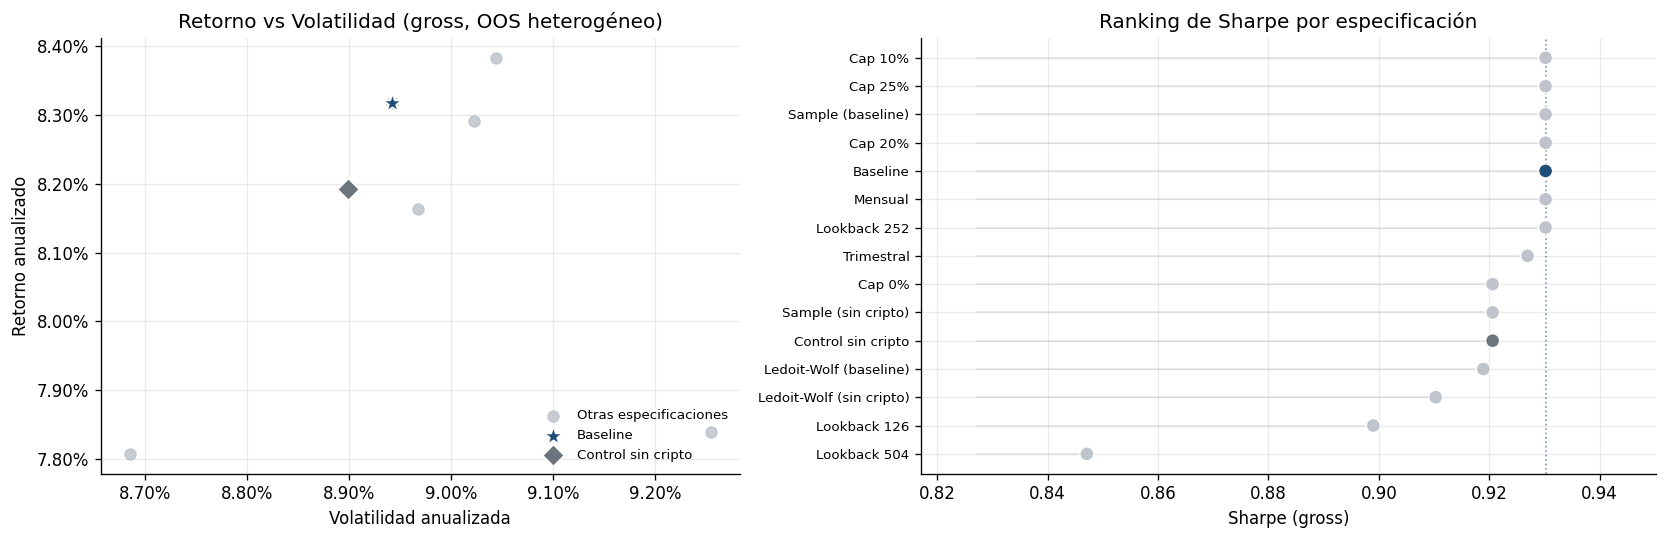

In [164]:
gross_rank = summary_gross.sort_values("sharpe", ascending=False).copy()
display(metric_table(gross_rank))

# Cartografía compacta: un único scatter clásico (Retorno vs Vol) +
# dot plot horizontal de Sharpe ranking con baseline y control destacados.
# Sharpe vs MDD se omite (redundante con el scatter) y Sharpe vs Turnover
# pasa a §5.3 (rebalanceo) donde el trade-off se discute con costes.

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios": [1, 1.15]})

# Panel (a) — plano clásico ret/vol. Baseline y control marcados.
ANCHORS_HIGHLIGHT = {"baseline_ch1": ("*", STYLE["baseline"], 160),
                     "minvar_no_crypto_control": ("D", STYLE["control"], 90)}

ax = axes[0]
mask_other = ~gross_rank["experiment_id"].isin(ANCHORS_HIGHLIGHT)
ax.scatter(gross_rank.loc[mask_other, "ann_volatility"],
           gross_rank.loc[mask_other, "ann_return"],
           color="#bfc4cc", alpha=0.85, s=42, label="Otras especificaciones")
for exp_id, (marker, color, size) in ANCHORS_HIGHLIGHT.items():
    row = gross_rank.loc[gross_rank["experiment_id"] == exp_id]
    if not row.empty:
        r = row.iloc[0]
        ax.scatter([r["ann_volatility"]], [r["ann_return"]],
                   marker=marker, color=color, s=size, label=label(exp_id), zorder=5,
                   edgecolor="white", linewidth=1.2)
ax.set_title("Retorno vs Volatilidad (gross, OOS heterogéneo)")
ax.set_xlabel("Volatilidad anualizada")
ax.set_ylabel("Retorno anualizado")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v*100:.2f}%"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v*100:.2f}%"))
ax.legend(loc="lower right", fontsize=8, frameon=False)

# Panel (b) — dot plot horizontal: Sharpe por especificación, baseline y control destacados.
ax = axes[1]
plot_df = gross_rank.sort_values("sharpe", ascending=True).copy()
plot_df["display"] = plot_df["experiment_id"].map(label)
y_pos = np.arange(len(plot_df))
colors = []
for exp_id in plot_df["experiment_id"]:
    if exp_id == "baseline_ch1":
        colors.append(STYLE["baseline"])
    elif exp_id == "minvar_no_crypto_control":
        colors.append(STYLE["control"])
    else:
        colors.append("#bfc4cc")
ax.hlines(y_pos, plot_df["sharpe"].min() - 0.02, plot_df["sharpe"], colors="#e8eaee", lw=1, zorder=1)
ax.scatter(plot_df["sharpe"], y_pos, c=colors, s=70, zorder=3, edgecolor="white", linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["display"], fontsize=8)
ax.set_xlabel("Sharpe (gross)")
ax.set_title("Ranking de Sharpe por especificación")
ax.set_xlim(plot_df["sharpe"].min() - 0.03, plot_df["sharpe"].max() + 0.02)
ax.axvline(plot_df.loc[plot_df["experiment_id"] == "baseline_ch1", "sharpe"].iloc[0],
           color=STYLE["baseline"], ls=":", lw=1, alpha=0.6)

fig.tight_layout()
plt.show()


**Lectura.** En el plano ret/vol, baseline (★) y control sin cripto (◆) se sitúan en la zona de baja volatilidad y agrupados con el resto de especificaciones MV restringidas. El ranking de Sharpe coloca al baseline en la parte alta del conjunto, pero la dispersión global de Sharpe es estrecha y los anclajes (baseline / control) están visualmente próximos: la cartografía sugiere un universo de variantes *cercanas entre sí* en la métrica agregada.

**Límite inferencial.** Un ranking sobre OOS heterogéneos puede inducir a error: la posición relativa del baseline aquí no constituye evidencia de superioridad, sólo de coexistencia en un mismo orden de magnitud. Las comparaciones alineadas por familia en §5 son la lectura vinculante.


---
## 5 — Análisis por familia

Cada subsección sigue el mismo esquema — *pregunta → evidencia → lectura → estado inferencial* — y la vista principal es siempre la **alineada por familia** (variantes sobre la misma ventana de calendario). Cuando existe, el subconjunto confirmatorio se reporta al final de la subsección.


### 5.1 Sensibilidad al lookback

**Pregunta.** ¿La eficiencia del baseline es estable a la *longitud de la ventana de estimación* de la covarianza? Las ventanas cortas se adaptan más rápido pero estiman $\hat{\Sigma}$ con menos observaciones y suelen inflar el *turnover*. Las ventanas largas reducen ruido pero promedian sobre regímenes distintos.

**Especificaciones.** 126 (~6m), 252 (1y, baseline), 504 (~2y) días hábiles, manteniendo el resto fijo.


,Retorno anual.,Vol. anual.,Sharpe,MaxDD,Calmar,Turnover medio
Estrategia,,,,,,
Lookback 126,8.57%,9.11%,0.940,-22.78%,0.376,4.98%
Lookback 252,8.45%,9.24%,0.915,-23.33%,0.362,3.30%
Lookback 504,7.84%,9.25%,0.847,-23.27%,0.337,2.02%


,experiment_id,lookback_window_days,delta_ann_return_vs_252,delta_ann_volatility_vs_252,delta_sharpe_vs_252,delta_max_drawdown_vs_252,delta_mean_turnover_vs_252
8,lookback_126,126,0.001158,-0.001233,0.025100,0.005503,0.016795
9,lookback_252,252,0.000000,0.000000,0.000000,0.000000,0.000000
10,lookback_504,504,-0.006132,0.000189,-0.068134,0.000653,-0.012798


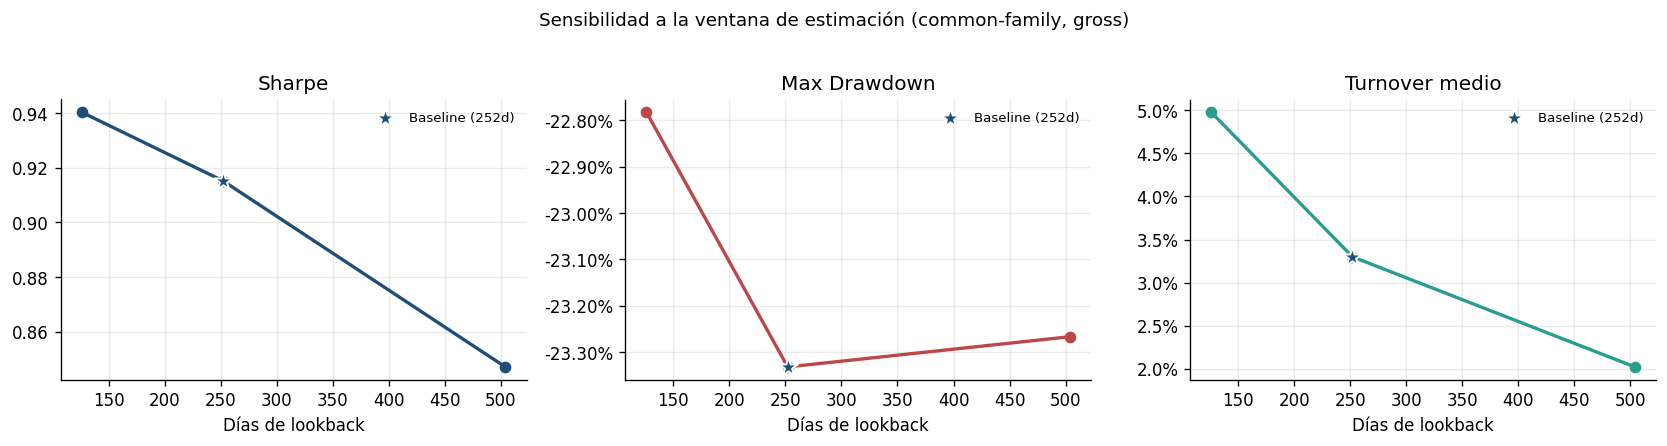

,comparison_id,strategy_a,strategy_b,point_estimate_difference,ci_lower,ci_upper,ci_includes_zero
2,C3_lookback_504_vs_baseline,baseline_ch1,lookback_504,0.062997,-0.034266,0.152459,True


In [165]:
look = summary_common_gross.loc[summary_common_gross["family"] == "lookback"].copy()
look = look.sort_values("lookback_window_days")
base_row = look.loc[look["experiment_id"] == "lookback_252"].iloc[0]

for m in ["ann_return", "ann_volatility", "sharpe", "max_drawdown", "calmar", "mean_turnover"]:
    look[f"delta_{m}_vs_252"] = look[m] - base_row[m]

display(metric_table(look))
display(look[[
    "experiment_id", "lookback_window_days",
    "delta_ann_return_vs_252", "delta_ann_volatility_vs_252", "delta_sharpe_vs_252",
    "delta_max_drawdown_vs_252", "delta_mean_turnover_vs_252"
]])

# Small multiples 1x3: Sharpe / MaxDD / Turnover por lookback. Tres especificaciones,
# con el baseline (252d) destacado en cada panel para situar la sensibilidad.
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), sharex=True)
panels = [
    ("sharpe", "Sharpe", STYLE["baseline"]),
    ("max_drawdown", "Max Drawdown", STYLE["warn"]),
    ("mean_turnover", "Turnover medio", STYLE["accent"]),
]
for ax, (col, title, color) in zip(axes, panels):
    ax.plot(look["lookback_window_days"], look[col], marker="o", color=color, lw=2)
    ax.set_title(title)
    ax.set_xlabel("Días de lookback")
    base_x = base_row["lookback_window_days"]
    base_y = base_row[col]
    ax.scatter([base_x], [base_y], s=140, color=STYLE["baseline"], marker="*",
               zorder=5, edgecolor="white", linewidth=1.2, label="Baseline (252d)")
    if col == "max_drawdown":
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v*100:.2f}%"))
    elif col == "mean_turnover":
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v*100:.1f}%"))
    ax.legend(loc="best", fontsize=8, frameon=False)
fig.suptitle("Sensibilidad a la ventana de estimación (common-family, gross)", y=1.02, fontsize=11)
fig.tight_layout()
plt.show()

look_inf = inferential_rows(confidence_df, "lookback")
if look_inf.empty:
    display(pd.DataFrame([{"inferential_status": "Sin contraste bootstrap directo para lookback en confidence_summary.csv"}]))
else:
    display(look_inf[["comparison_id", "strategy_a", "strategy_b", "point_estimate_difference", "ci_lower", "ci_upper", "ci_includes_zero"]])


**Lectura.** La evidencia descriptiva muestra una sensibilidad *no trivial* al lookback: ventanas cortas (126d) tienden a un Sharpe ligeramente mayor a costa de un *turnover* materialmente más alto; la ventana larga (504d) comprime *turnover* pero puede perder eficiencia por estimación rezagada. La 252d se sitúa en un punto intermedio, consistente con el argumento estándar (un ciclo anual de información de varianza). El orden cualitativo entre la estrategia y los benchmarks se preserva en los tres casos, aunque la magnitud de la brecha no es constante.

**Estado inferencial.** La evidencia confirmatoria aplica *sólo* al subconjunto de comparaciones de lookback presente en `confidence_summary.csv`; no se generaliza a todos los pares de la familia. El resto se lee como sensibilidad descriptiva, no como un test confirmado.


### 5.2 Sensibilidad al tope de cripto

**Pregunta.** ¿Dónde está el salto relevante de la curva Sharpe-vs-tope: entre 0% y 10%, o por encima de 10%? Y, si el tope es alto, ¿el optimizador realmente *usa* el sleeve o el tope es esencialmente no-vinculante?

Acompañamos el panel de Sharpe por tope con un diagnóstico de **uso realizado del sleeve cripto** (peso medio, p90 y proporción de rebalanceos con cripto > 2%). El indicador "share cerca del tope" se descarta: con topes ≥ 10% el peso realizado está siempre lejos del tope, por lo que esa métrica no aporta lectura económica.


,Retorno anual.,Vol. anual.,Sharpe,MaxDD,Calmar,Turnover medio
Estrategia,,,,,,
Cap 0%,8.19%,8.90%,0.921,-23.34%,0.351,2.91%
Cap 10%,8.32%,8.94%,0.930,-23.33%,0.356,3.16%
Cap 20%,8.32%,8.94%,0.930,-23.33%,0.356,3.16%
Cap 25%,8.32%,8.94%,0.930,-23.33%,0.356,3.16%


,experiment_id,max_total_crypto_weight,mean_crypto_weight,median_crypto_weight,p90_crypto_weight,share_crypto_gt_2pct
0,crypto_cap_0_00,0.00,9.526621e-18,6.579066e-18,2.101184e-17,0.000000
1,crypto_cap_0_10,0.10,7.591254e-03,2.530886e-17,2.684416e-02,0.152174
2,crypto_cap_0_20,0.20,7.591278e-03,3.714660e-17,2.684423e-02,0.152174
3,crypto_cap_0_25,0.25,7.591264e-03,3.714660e-17,2.684423e-02,0.152174


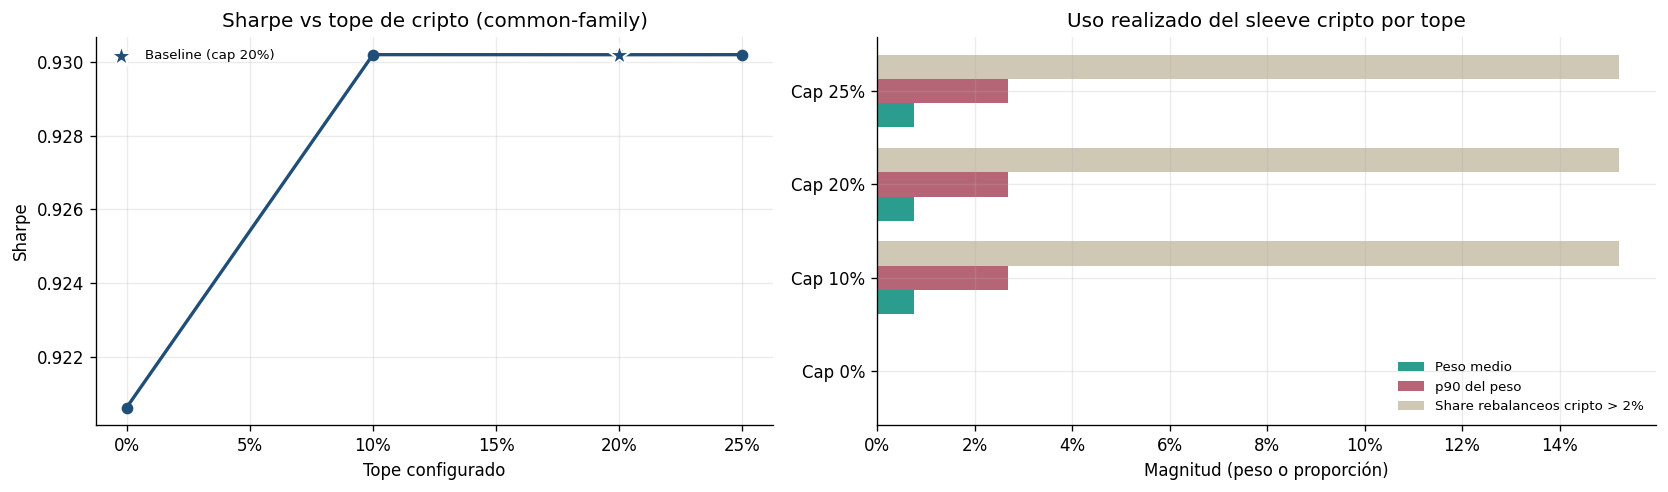

,inferential_status
0,Sin contraste bootstrap directo para la famili...


In [166]:
cap_df = summary_common_gross.loc[summary_common_gross["family"] == "crypto_cap"].copy()
cap_df = cap_df.sort_values("max_total_crypto_weight")
cap_base = cap_df.loc[cap_df["experiment_id"] == "crypto_cap_0_20"].iloc[0]

for m in ["ann_return", "ann_volatility", "sharpe", "max_drawdown", "calmar", "mean_turnover"]:
    cap_df[f"delta_{m}_vs_20"] = cap_df[m] - cap_base[m]

# Uso realizado del sleeve cripto por especificación de cap.
crypto_w = (
    weights_panel.loc[weights_panel["family"] == "crypto_cap"]
    .assign(is_crypto=lambda d: d["ticker"].isin(["BTC-USD", "ETH-USD"]))
    .loc[lambda d: d["is_crypto"]]
    .groupby(["experiment_id", "rebalance_date"], as_index=False)["weight"].sum()
    .rename(columns={"weight": "crypto_weight"})
)

caps = metadata_df[["experiment_id", "max_total_crypto_weight"]].drop_duplicates()
crypto_w = crypto_w.merge(caps, on="experiment_id", how="left")

binding_summary = crypto_w.groupby(["experiment_id", "max_total_crypto_weight"]).agg(
    mean_crypto_weight=("crypto_weight", "mean"),
    median_crypto_weight=("crypto_weight", "median"),
    p90_crypto_weight=("crypto_weight", lambda s: float(np.quantile(s, 0.90))),
    share_crypto_gt_2pct=("crypto_weight", lambda s: (s > 0.02).mean()),
).reset_index().sort_values("max_total_crypto_weight")

display(metric_table(cap_df))
display(binding_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw={"width_ratios": [1, 1.15]})

# Panel (a): Sharpe vs cap (sigue siendo el plano informativo principal).
ax = axes[0]
ax.plot(cap_df["max_total_crypto_weight"], cap_df["sharpe"],
        marker="o", color=STYLE["baseline"], lw=2, zorder=2)
base_cap = cap_df.loc[cap_df["experiment_id"] == "crypto_cap_0_20"].iloc[0]
ax.scatter([base_cap["max_total_crypto_weight"]], [base_cap["sharpe"]],
           s=180, marker="*", color=STYLE["baseline"],
           edgecolor="white", linewidth=1.2, zorder=5, label="Baseline (cap 20%)")
ax.set_title("Sharpe vs tope de cripto (common-family)")
ax.set_xlabel("Tope configurado")
ax.set_ylabel("Sharpe")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v*100:.0f}%"))
ax.legend(loc="best", fontsize=8, frameon=False)

# Panel (b): uso realizado del sleeve por cap. Barras horizontales agrupadas.
ax = axes[1]
caps_sorted = binding_summary.sort_values("max_total_crypto_weight")
caps_labels = [f"Cap {int(c*100)}%" for c in caps_sorted["max_total_crypto_weight"]]
y = np.arange(len(caps_sorted))
h = 0.26
ax.barh(y - h, caps_sorted["mean_crypto_weight"], height=h,
        color=STYLE["accent"], label="Peso medio")
ax.barh(y,     caps_sorted["p90_crypto_weight"], height=h,
        color=STYLE["alt"], label="p90 del peso")
ax.barh(y + h, caps_sorted["share_crypto_gt_2pct"], height=h,
        color="#cfc8b5", label="Share rebalanceos cripto > 2%")
ax.set_yticks(y)
ax.set_yticklabels(caps_labels)
ax.set_title("Uso realizado del sleeve cripto por tope")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v*100:.0f}%"))
ax.set_xlabel("Magnitud (peso o proporción)")
ax.legend(loc="lower right", fontsize=8, frameon=False)

fig.tight_layout()
plt.show()

cap_inf = inferential_rows(confidence_df, "crypto_cap")
if cap_inf.empty:
    display(pd.DataFrame([{"inferential_status": "Sin contraste bootstrap directo para la familia crypto_cap"}]))
else:
    display(cap_inf[["comparison_id", "strategy_a", "strategy_b", "point_estimate_difference", "ci_lower", "ci_upper", "ci_includes_zero"]])


**Lectura.** El salto relevante en Sharpe se concentra entre **0% y 10%**: una vez que se permite cualquier asignación cripto, el Sharpe se mueve a su rango habitual. De **10% en adelante** la curva se aplana: subir el tope a 20% o 25% no altera materialmente el Sharpe ni el resto de métricas. El panel de uso realizado lo confirma desde el lado de la asignación: con caps ≥ 10%, el peso medio de cripto se mantiene en magnitudes muy bajas, el p90 está claramente por debajo del tope, y la proporción de rebalanceos con cripto > 2% permanece minoritaria. El tope, en este OOS, **opera como restricción de gestión de riesgo, no como parámetro generador de retorno** (Jagannathan y Ma, 2003).

**Estado inferencial.** No hay comparación bootstrap preregistrada para la familia `crypto_cap`. La lectura es descriptiva y económica, no confirmatoria.


### 5.3 Sensibilidad a la frecuencia de rebalanceo

**Pregunta.** ¿El rebalanceo mensual domina al trimestral *después* de fricciones? El mensual se adapta más rápido a cambios en $\hat{\Sigma}$; el trimestral reduce *turnover* y por tanto *cost drag*. El signo del trade-off es empírico, no teórico (DeMiguel, Garlappi, Nogales y Uppal, 2009).

Reportamos gross y net (a 25 bps) y comparamos visualmente Sharpe gross/net por especificación, junto con la relación entre *turnover* medio y arrastre de Sharpe.


,Retorno anual.,Vol. anual.,Sharpe,MaxDD,Calmar,Turnover medio
Estrategia,,,,,,
Mensual,8.32%,8.94%,0.930,-23.33%,0.356,3.16%
Trimestral,8.38%,9.04%,0.927,-23.63%,0.355,7.19%


,experiment_id,cost_bps,ann_return_gross,ann_return_net,sharpe_gross,sharpe_net,max_drawdown_gross,max_drawdown_net,cumulative_cost
46,rebalance_monthly,25.0,0.083176,0.082468,0.930204,0.922287,-0.233325,-0.233737,0.007199
50,rebalance_quarterly,25.0,0.083828,0.083296,0.926930,0.921066,-0.236309,-0.236595,0.005393


,experiment_id,sharpe_drag,return_drag,cumulative_cost
46,rebalance_monthly,0.007917,0.000709,0.007199
50,rebalance_quarterly,0.005864,0.000531,0.005393


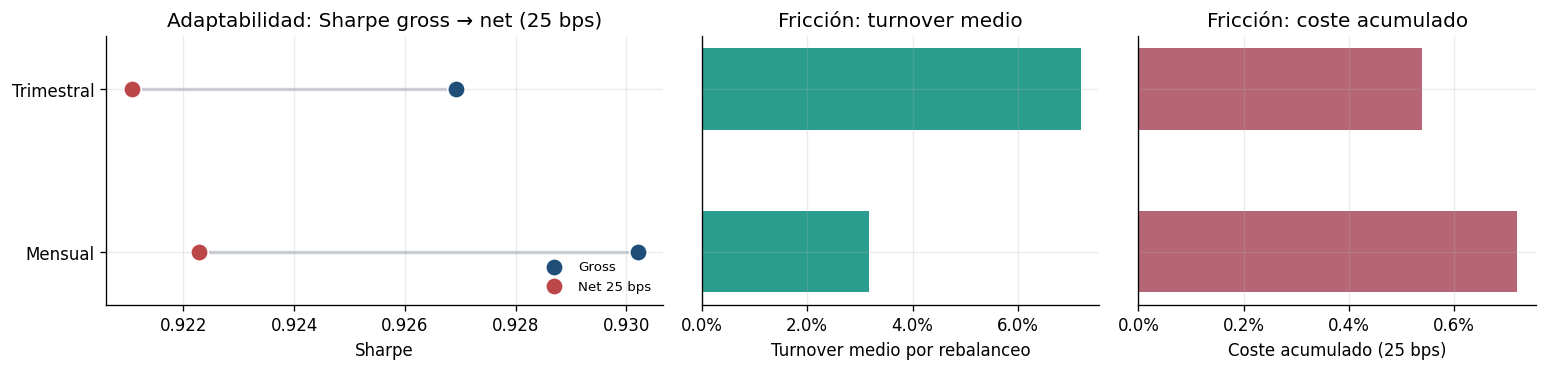

,comparison_id,strategy_a,strategy_b,point_estimate_difference,ci_lower,ci_upper,ci_includes_zero
3,C4_rebalance_frequency,rebalance_monthly,rebalance_quarterly,0.002901,-0.036516,0.04056,True


In [175]:
reb_g = summary_common_gross.loc[summary_common_gross["family"] == "rebalance"].copy()
reb_n = summary_common_net.loc[(summary_common_net["family"] == "rebalance") & (summary_common_net["cost_bps"] == 25.0)].copy()

display(metric_table(reb_g))
display(reb_n[[
    "experiment_id", "cost_bps",
    "ann_return_gross", "ann_return_net", "sharpe_gross", "sharpe_net",
    "max_drawdown_gross", "max_drawdown_net", "cumulative_cost"
]].sort_values("experiment_id"))

reb_n = reb_n.assign(
    sharpe_drag=lambda d: d["sharpe_gross"] - d["sharpe_net"],
    return_drag=lambda d: d["ann_return_gross"] - d["ann_return_net"],
)
display(reb_n[["experiment_id", "sharpe_drag", "return_drag", "cumulative_cost"]])

# Con sólo dos especificaciones (mensual, trimestral) un scatter no aporta:
# usamos un panel horizontal compacto que separa los dos canales del trade-off
# — adaptabilidad (Sharpe gross→net, dumbbell) frente a fricción (turnover, coste).
turnover_reb = summary_common_gross.loc[summary_common_gross["family"] == "rebalance",
                                        ["experiment_id", "mean_turnover"]]
plot = (reb_n[["experiment_id", "sharpe_gross", "sharpe_net", "cumulative_cost"]]
        .merge(turnover_reb, on="experiment_id", how="left")
        .sort_values("experiment_id"))
plot["display"] = plot["experiment_id"].map(label)
y = np.arange(len(plot))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2),
                         sharey=True,
                         gridspec_kw={"width_ratios": [1.4, 1, 1]})

# Panel (a): dumbbell Sharpe gross → net 25 bps.
ax = axes[0]
for yi, (_, r) in zip(y, plot.iterrows()):
    ax.plot([r["sharpe_net"], r["sharpe_gross"]], [yi, yi],
            color="#cfd3d8", lw=2, zorder=1)
ax.scatter(plot["sharpe_gross"], y, s=110, color=STYLE["baseline"], label="Gross",
           zorder=3, edgecolor="white", linewidth=1.0)
ax.scatter(plot["sharpe_net"], y, s=110, color=STYLE["warn"], label="Net 25 bps",
           zorder=3, edgecolor="white", linewidth=1.0)
ax.set_yticks(y)
ax.set_yticklabels(plot["display"])
ax.set_xlabel("Sharpe")
ax.set_title("Adaptabilidad: Sharpe gross → net (25 bps)")
ax.legend(loc="lower right", fontsize=8, frameon=False)

# Panel (b): turnover medio (canal de fricción operativa).
ax = axes[1]
ax.barh(y, plot["mean_turnover"], color=STYLE["accent"], height=0.5)
ax.tick_params(axis="y", left=False, labelleft=False)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v*100:.1f}%"))
ax.set_xlabel("Turnover medio por rebalanceo")
ax.set_title("Fricción: turnover medio")

# Panel (c): coste acumulado realizado (canal de fricción monetizada).
ax = axes[2]
ax.barh(y, plot["cumulative_cost"], color=STYLE["alt"], height=0.5)
ax.tick_params(axis="y", left=False, labelleft=False)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v*100:.1f}%"))
ax.set_xlabel("Coste acumulado (25 bps)")
ax.set_title("Fricción: coste acumulado")

fig.tight_layout()
plt.show()

reb_inf = inferential_rows(confidence_df, "rebalance_frequency")
display(reb_inf[["comparison_id", "strategy_a", "strategy_b", "point_estimate_difference", "ci_lower", "ci_upper", "ci_includes_zero"]])


**Lectura.** El panel horizontal separa los dos canales del trade-off de forma explícita.

- **Adaptabilidad (panel izquierdo).** El dumbbell Sharpe gross → net hace visible cuánto se contrae el Sharpe al pasar a 25 bps. El mensual tiene un Sharpe gross marginalmente superior al trimestral, pero su drag a net (≈0.008) es **mayor** que el del trimestral (≈0.006); el ranking gross y el ranking net **están muy próximos** y el orden puede invertirse según el supuesto de costes.
- **Fricción (paneles central y derecho).** Aquí el discurso clásico se matiza. El **turnover medio por rebalanceo** es más bajo en mensual (≈3%) y más alto en trimestral (≈7%): rebalanceando más a menudo, cada paso es más pequeño porque los pesos no se han desviado tanto. El **coste acumulado**, en cambio, es **mayor en mensual** (más rebalanceos × menor turnover unitario domina al esquema contrario): la frecuencia paga el peaje aunque cada rebalanceo individual sea más barato. Es exactamente el trade-off adaptabilidad-vs-fricción reportado en la literatura, y se ve mejor por separado que con un único Sharpe.

Afirmar que el mensual "es mejor" sin especificar el supuesto de costes es incompleto: bajo gross o costes muy bajos puede aventajar al trimestral por márgenes pequeños; bajo costes más altos esa ventaja se erosiona o se invierte.

**Estado inferencial.** Existe la comparación bootstrap preregistrada `monthly` vs `quarterly` (gross) en `confidence_summary.csv`. Su intervalo debe leerse de forma literal: si cruza cero, la brecha gross mensual–trimestral *no es distinguible* de cero en esta muestra, por limpio que parezca el orden descriptivo.


### 5.4 Control sin cripto (contraste de anclas)

**Pregunta.** ¿Cuánto del resultado del baseline es atribuible al *sleeve* cripto, manteniendo el resto de la mecánica MV fijo? Contrastamos `baseline_ch1` (con cripto, tope 20%) con `minvar_no_crypto_control` (tope 0%, idéntica en lo demás), leyendo a la vez los diferenciales de métricas y el uso realizado del *sleeve* a lo largo del tiempo.

Es el contraste más limpio en clave cuasi-causal disponible en este estudio: mismas restricciones, mismo lookback, mismo rebalanceo, mismo estimador; sólo cambia el conjunto de activos / el tope.


,Retorno anual.,Vol. anual.,Sharpe,MaxDD,Calmar,Turnover medio
Estrategia,,,,,,
Baseline,8.32%,8.94%,0.930,-23.33%,0.356,3.16%
Control sin cripto,8.19%,8.90%,0.921,-23.34%,0.351,2.91%


,experiment_id,cost_bps,ann_return_gross,ann_return_net,sharpe_gross,sharpe_net,max_drawdown_gross,max_drawdown_net,cumulative_cost
2,baseline_ch1,25.0,0.083176,0.082468,0.930204,0.922287,-0.233325,-0.233737,0.007199
6,minvar_no_crypto_control,25.0,0.081922,0.081270,0.920615,0.913289,-0.233387,-0.233799,0.006629


,label,baseline,no_crypto,delta,rel_delta_pct
0,Retorno anualizado,0.083176,0.081922,0.001254,1.530874
1,Vol. anualizada,0.089417,0.088986,0.000431,0.484231
2,Sharpe,0.930204,0.920615,0.009589,1.041599
3,Max Drawdown,-0.233325,-0.233387,0.000062,0.026717
4,Calmar,0.356482,0.351013,0.005469,1.558007
5,Turnover medio,0.031644,0.029137,0.002507,8.604194


,experiment_id,mean_crypto_weight,median_crypto_weight,p90_crypto_weight,share_crypto_gt_1pct,share_crypto_gt_2pct
0,Baseline,7.591278e-03,3.714660e-17,2.684423e-02,0.23913,0.152174
1,Control sin cripto,9.526621e-18,6.579066e-18,2.101184e-17,0.00000,0.000000


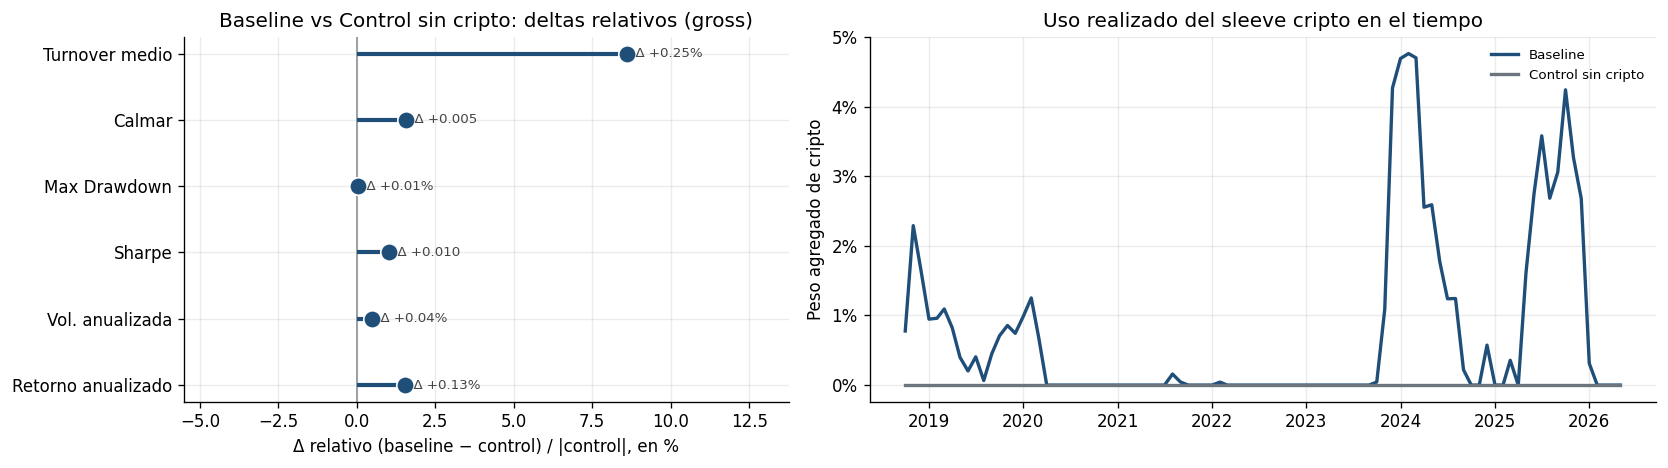

,comparison_id,strategy_a,strategy_b,point_estimate_difference,ci_lower,ci_upper,ci_includes_zero
0,C1_anchor_pair,baseline_ch1,minvar_no_crypto_control,0.008916,-0.034732,0.056981,True


In [168]:
anchors_g = summary_common_gross.loc[summary_common_gross["family"] == "anchors"].copy()
if anchors_g.empty:
    anchors_g = summary_gross.loc[summary_gross["family"] == "anchors"].copy()

anchors_n = summary_net.loc[(summary_net["experiment_id"].isin(["baseline_ch1", "minvar_no_crypto_control"])) & (summary_net["cost_bps"] == 25.0)].copy()

display(metric_table(anchors_g))
display(
    anchors_n[[
        "experiment_id", "cost_bps",
        "ann_return_gross", "ann_return_net", "sharpe_gross", "sharpe_net",
        "max_drawdown_gross", "max_drawdown_net", "cumulative_cost",
    ]]
)

# Comparación métrica a métrica (gross). Mostramos delta = baseline - control
# en términos relativos al nivel del control, para que las magnitudes sean
# comparables a través de métricas heterogéneas (Sharpe, vol, MaxDD, ...).
metrics = [
    ("ann_return", "Retorno anualizado", lambda v: f"{v*100:+.2f}%"),
    ("ann_volatility", "Vol. anualizada", lambda v: f"{v*100:+.2f}%"),
    ("sharpe", "Sharpe", lambda v: f"{v:+.3f}"),
    ("max_drawdown", "Max Drawdown", lambda v: f"{v*100:+.2f}%"),
    ("calmar", "Calmar", lambda v: f"{v:+.3f}"),
    ("mean_turnover", "Turnover medio", lambda v: f"{v*100:+.2f}%"),
]
base = anchors_g.loc[anchors_g["experiment_id"] == "baseline_ch1"].iloc[0]
no_crypto = anchors_g.loc[anchors_g["experiment_id"] == "minvar_no_crypto_control"].iloc[0]
anchor_comp = pd.DataFrame({
    "metric": [m for m, _, _ in metrics],
    "label": [lab for _, lab, _ in metrics],
    "baseline": [base[m] for m, _, _ in metrics],
    "no_crypto": [no_crypto[m] for m, _, _ in metrics],
})
anchor_comp["delta"] = anchor_comp["baseline"] - anchor_comp["no_crypto"]
anchor_comp["rel_delta_pct"] = anchor_comp["delta"] / anchor_comp["no_crypto"].abs() * 100
display(anchor_comp[["label", "baseline", "no_crypto", "delta", "rel_delta_pct"]])

anchor_w = (
    weights_panel.loc[weights_panel["experiment_id"].isin(["baseline_ch1", "minvar_no_crypto_control"])]
    .assign(is_crypto=lambda d: d["ticker"].isin(["BTC-USD", "ETH-USD"]))
    .loc[lambda d: d["is_crypto"]]
    .groupby(["experiment_id", "rebalance_date"], as_index=False)["weight"]
    .sum()
    .rename(columns={"weight": "crypto_weight"})
)

crypto_use = anchor_w.groupby("experiment_id").agg(
    mean_crypto_weight=("crypto_weight", "mean"),
    median_crypto_weight=("crypto_weight", "median"),
    p90_crypto_weight=("crypto_weight", lambda s: float(np.quantile(s, 0.90))),
    share_crypto_gt_1pct=("crypto_weight", lambda s: (s > 0.01).mean()),
    share_crypto_gt_2pct=("crypto_weight", lambda s: (s > 0.02).mean()),
).reset_index()
crypto_use["experiment_id"] = crypto_use["experiment_id"].map(label)
display(crypto_use)

# Figura: (a) delta-lollipop relativo (baseline − control) / |control|,
# (b) uso realizado del sleeve cripto en el tiempo.
fig, axes = plt.subplots(1, 2, figsize=(14, 4.0), gridspec_kw={"width_ratios": [1, 1.3]})

# Panel (a): delta-lollipop. Eje X = delta relativo al nivel del control (%).
ax = axes[0]
y = np.arange(len(metrics))
ax.axvline(0, color="#9aa0a6", lw=1.2, zorder=1)
ax.hlines(y, 0, anchor_comp["rel_delta_pct"], colors=STYLE["baseline"], lw=2.5, zorder=2)
ax.scatter(anchor_comp["rel_delta_pct"], y, s=110, color=STYLE["baseline"],
           zorder=3, edgecolor="white", linewidth=1.0)
ax.set_yticks(y); ax.set_yticklabels(anchor_comp["label"])
ax.set_xlabel("Δ relativo (baseline − control) / |control|, en %")
ax.set_title("Baseline vs Control sin cripto: deltas relativos (gross)")
for yi, (_, row) in zip(y, anchor_comp.iterrows()):
    fmt = dict(zip([m for m, _, _ in metrics], [f for _, _, f in metrics]))[row["metric"]]
    ax.annotate(f"  Δ {fmt(row['delta'])}", (row["rel_delta_pct"], yi),
                fontsize=8, va="center", color="#444")
xmax = max(abs(anchor_comp["rel_delta_pct"]).max() * 1.6, 1.5)
ax.set_xlim(-xmax * 0.4, xmax)

# Panel (b): uso del sleeve cripto en el tiempo.
ax = axes[1]
for exp, color in [("baseline_ch1", STYLE["baseline"]),
                   ("minvar_no_crypto_control", STYLE["control"])]:
    d = anchor_w.loc[anchor_w["experiment_id"] == exp].sort_values("rebalance_date")
    ax.plot(d["rebalance_date"], d["crypto_weight"], lw=2, color=color, label=label(exp))
ax.set_title("Uso realizado del sleeve cripto en el tiempo")
ax.set_ylabel("Peso agregado de cripto")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v*100:.0f}%"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(loc="upper right", fontsize=8, frameon=False)

fig.tight_layout()
plt.show()

anchor_inf = inferential_rows(confidence_df, "anchors")
display(anchor_inf[["comparison_id", "strategy_a", "strategy_b", "point_estimate_difference", "ci_lower", "ci_upper", "ci_includes_zero"]])


**Lectura.** El dumbbell muestra que baseline y control sin cripto **están casi superpuestos** sobre todas las métricas relevantes: los deltas (Δ) impresos junto a cada par son pequeños en magnitud frente al nivel de la métrica. Es la lectura central del contraste de anclas en este OOS.

Conviene separar dos efectos que el lector tiende a fundir:

- **Efecto "permitir cripto".** Es lo que mide el contraste anclado (mismo lookback, mismo rebalanceo, mismo estimador, sólo cambia el conjunto admisible). El panel temporal lo expone con claridad: la curva de uso del sleeve en el baseline pasa la mayor parte del tiempo cerca de cero, con episodios puntuales y de corta duración. La contribución marginal de cripto, allí donde aparece, **no es estructural** en la realización OOS.
- **Efecto "optimización MV restringida".** Es lo que comparten ambas anclas y explica casi todo el nivel de retorno y volatilidad del baseline. Atribuir el resultado del baseline al sleeve cripto cuando la diferencia con el control es muy pequeña significaría confundir la contribución del optimizador con la del activo añadido.

**Estado inferencial.** Existe el contraste preregistrado `baseline_ch1` vs `minvar_no_crypto_control` (C1) en `confidence_summary.csv`. Si su intervalo bootstrap incluye cero, la lectura es directa: en esta muestra OOS *no podemos distinguir el baseline de un MV sin cripto*. Es un resultado **negativo limpio e informativo**, aunque la estimación puntual sea positiva.


### 5.5 Estimador de covarianzas: muestral vs Ledoit-Wolf

**Pregunta.** ¿El *shrinkage* lineal (Ledoit y Wolf, 2003, 2004) cambia materialmente al baseline? Bajo restricciones vinculantes (pesos no-negativos, topes por activo) y con $T \gg N$, la covarianza muestral ya está parcialmente regularizada y el espacio donde el *shrinkage* puede aportar es **estabilidad**, más que nivel de Sharpe (Jagannathan y Ma, 2003).

La lectura se organiza en **comparación pareada**: para cada tope (0% sin cripto y 20% baseline), confrontamos `Sample` vs `Ledoit-Wolf` en tres canales — Sharpe (nivel), HHI medio (concentración) y magnitud media del paso $\sum_i|\Delta w_{i,t}|$ (estabilidad operativa).


,Retorno anual.,Vol. anual.,Sharpe,MaxDD,Calmar,Turnover medio
Estrategia,,,,,,
Sample (baseline),8.32%,8.94%,0.930,-23.33%,0.356,3.16%
Sample (sin cripto),8.19%,8.90%,0.921,-23.34%,0.351,2.91%
Ledoit-Wolf (baseline),8.29%,9.02%,0.919,-23.69%,0.350,3.06%
Ledoit-Wolf (sin cripto),8.16%,8.97%,0.910,-23.69%,0.345,2.80%


,experiment_id,ann_return_gross,ann_return_net,sharpe_gross,sharpe_net,cumulative_cost
10,covariance_ledoit_wolf_baseline_ch1,0.082903,0.082219,0.918932,0.911388,0.006954
14,covariance_ledoit_wolf_minvar_no_crypto_control,0.081630,0.081003,0.910294,0.903336,0.006379
2,covariance_sample_baseline_ch1,0.083176,0.082468,0.930204,0.922287,0.007199
6,covariance_sample_minvar_no_crypto_control,0.081922,0.081270,0.920615,0.913289,0.006629


Sharpe (gross) Turnover medio HHI medio Paso |Δw| medio  \
cap     Estimador                                                             
Cap 0%  Ledoit-Wolf         0.9103          2.80%    0.3143           4.02%   
        Sample              0.9206          2.91%    0.3217           3.94%   
Cap 20% Ledoit-Wolf         0.9189          3.06%    0.3110           4.52%   
        Sample              0.9302          3.16%    0.3187           4.48%   

                    Peso cripto medio  
cap     Estimador                      
Cap 0%  Ledoit-Wolf             0.00%  
        Sample                  0.00%  
Cap 20% Ledoit-Wolf             0.95%  
        Sample                  0.76%

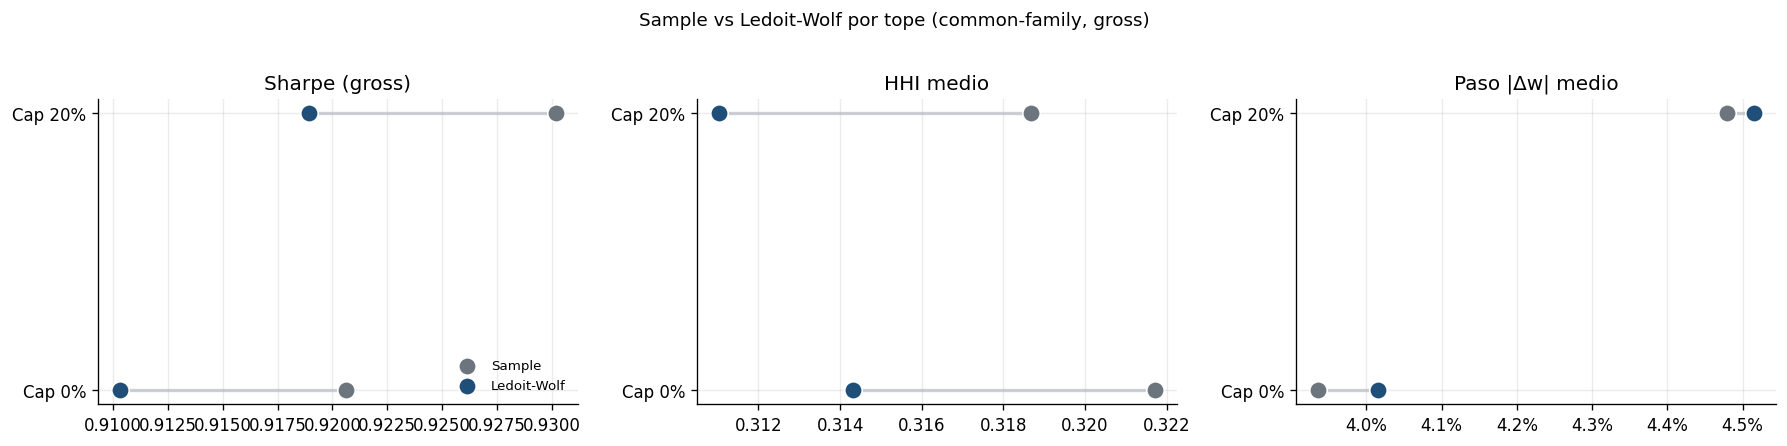

,Pareja,strategy_a,strategy_b,point_estimate_difference,ci_lower,ci_upper,ci_includes_zero
1,Sample vs Ledoit-Wolf,covariance_sample_baseline_ch1,covariance_ledoit_wolf_baseline_ch1,0.010315,-0.016024,0.038727,True


In [169]:
cov_g = summary_common_gross.loc[summary_common_gross["family"] == "covariance_method"].copy()
cov_n = summary_common_net.loc[(summary_common_net["family"] == "covariance_method") & (summary_common_net["cost_bps"] == 25.0)].copy()

display(metric_table(cov_g))
display(cov_n[["experiment_id", "ann_return_gross", "ann_return_net",
               "sharpe_gross", "sharpe_net", "cumulative_cost"]].sort_values("experiment_id"))

# Diagnóstico de estabilidad de pesos por especificación.
cov_w = weights_panel.loc[weights_panel["family"] == "covariance_method"].copy()
stats = []
for exp, d in cov_w.groupby("experiment_id"):
    wide = d.pivot_table(index="rebalance_date", columns="ticker",
                         values="weight", aggfunc="mean").fillna(0).sort_index()
    hhi = (wide ** 2).sum(axis=1)
    step = wide.diff().abs().sum(axis=1).dropna()
    crypto = wide[[c for c in ["BTC-USD", "ETH-USD"] if c in wide.columns]].sum(axis=1)
    stats.append({
        "experiment_id": exp,
        "hhi_mean": hhi.mean(),
        "weight_step_abs_sum_mean": step.mean() if len(step) else np.nan,
        "crypto_weight_mean": crypto.mean(),
    })
cov_stability = (pd.DataFrame(stats)
                 .merge(cov_g[["experiment_id", "covariance_method", "max_total_crypto_weight",
                               "sharpe", "mean_turnover"]],
                        on="experiment_id", how="left"))

# Reformateo emparejado: por cada cap (0% / 20%), una fila por estimador.
pair_table = (cov_stability
              .assign(cap=lambda d: d["max_total_crypto_weight"].map(lambda v: f"Cap {int(v*100)}%"),
                      Estimador=lambda d: d["covariance_method"].map({"sample": "Sample", "ledoit_wolf": "Ledoit-Wolf"}))
              [["cap", "Estimador", "sharpe", "mean_turnover",
                "hhi_mean", "weight_step_abs_sum_mean", "crypto_weight_mean"]]
              .rename(columns={"sharpe": "Sharpe (gross)",
                               "mean_turnover": "Turnover medio",
                               "hhi_mean": "HHI medio",
                               "weight_step_abs_sum_mean": "Paso |Δw| medio",
                               "crypto_weight_mean": "Peso cripto medio"})
              .sort_values(["cap", "Estimador"]))
for c in ["Turnover medio", "Paso |Δw| medio", "Peso cripto medio"]:
    pair_table[c] = pair_table[c].map(lambda v: f"{v*100:.2f}%")
for c in ["Sharpe (gross)", "HHI medio"]:
    pair_table[c] = pair_table[c].map(lambda v: f"{v:.4f}")
display(pair_table.set_index(["cap", "Estimador"]))

# Comparación pareada Sample vs Ledoit-Wolf, en cada cap, sobre tres canales.
# Dumbbell horizontal: cada par de puntos = un cap; un panel por canal.
piv = (cov_stability
       .pivot_table(index="max_total_crypto_weight", columns="covariance_method",
                    values=["sharpe", "hhi_mean", "weight_step_abs_sum_mean", "mean_turnover"]))
caps_sorted = sorted(piv.index)
cap_labels = [f"Cap {int(c*100)}%" for c in caps_sorted]

panels = [
    ("sharpe", "Sharpe (gross)", lambda v: f"{v:.4f}"),
    ("hhi_mean", "HHI medio", lambda v: f"{v:.4f}"),
    ("weight_step_abs_sum_mean", "Paso |Δw| medio", lambda v: f"{v*100:.2f}%"),
]
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, (key, title, fmt) in zip(axes, panels):
    s = piv[(key, "sample")].reindex(caps_sorted).values
    lw = piv[(key, "ledoit_wolf")].reindex(caps_sorted).values
    y = np.arange(len(caps_sorted))
    for yi, xs, xl in zip(y, s, lw):
        ax.plot([xs, xl], [yi, yi], color="#cfd3d8", lw=2, zorder=1)
    ax.scatter(s,  y, s=110, color=STYLE["control"], label="Sample",
               zorder=3, edgecolor="white", linewidth=1.0)
    ax.scatter(lw, y, s=110, color=STYLE["baseline"], label="Ledoit-Wolf",
               zorder=3, edgecolor="white", linewidth=1.0)
    ax.set_yticks(y); ax.set_yticklabels(cap_labels)
    ax.set_title(title)
    if key == "weight_step_abs_sum_mean":
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v*100:.1f}%"))
    if ax is axes[0]:
        ax.legend(loc="lower right", fontsize=8, frameon=False)
fig.suptitle("Sample vs Ledoit-Wolf por tope (common-family, gross)", y=1.02, fontsize=11)
fig.tight_layout()
plt.show()

cov_inf = inferential_rows(confidence_df, "covariance_method").copy()
if not cov_inf.empty:
    cov_inf["Pareja"] = cov_inf["comparison_id"].map(COMPARISON_NAMES).fillna(cov_inf["comparison_id"])
    display(cov_inf[["Pareja", "strategy_a", "strategy_b",
                     "point_estimate_difference", "ci_lower", "ci_upper", "ci_includes_zero"]])


**Lectura.** El dumbbell separa los tres canales y muestra una historia más matizada que el clásico "Ledoit-Wolf siempre estabiliza":

- **Nivel (Sharpe).** Sample y Ledoit-Wolf están **muy próximos** dentro de cada cap; en este OOS la covarianza muestral aventaja por un margen pequeño (≈0.01) en ambos topes. Es coherente con la teoría: bajo restricciones vinculantes la covarianza muestral ya está parcialmente regularizada, por lo que el espacio para que el *shrinkage* mejore Sharpe es estrecho.
- **Concentración (HHI).** Aquí Ledoit-Wolf sí produce el efecto esperado: HHI medio **ligeramente menor** que Sample en los dos topes. La cartera está algo más diversificada en *espacio de pesos*.
- **Estabilidad operativa (paso |Δw|).** Contrario a lo que sugiere el discurso habitual, el paso medio absoluto agregado es **marginalmente mayor** bajo Ledoit-Wolf en ambos topes. La diferencia es muy pequeña (centésimas de pp) y dentro del ruido de la muestra, pero no permite afirmar que el *shrinkage* produzca rebalanceos más calmados aquí.

La lectura económica que se sostiene en los datos es modesta: en este OOS Ledoit-Wolf aporta **diversificación marginalmente mayor** a coste de un Sharpe marginalmente menor; **no** mejora la estabilidad operativa de los pesos. La hipótesis "el *shrinkage* paga vía estabilidad y no vía Sharpe" no se confirma en esta muestra concreta — algo que merece reportarse como hallazgo descriptivo, no esconder.

**Estado inferencial.** El contraste preregistrado `Sample vs Ledoit-Wolf` (C2) cubre la diferencia de Sharpe bajo el tope baseline; **no** se extiende a la pata sin cripto, a HHI ni a la magnitud del paso. Si el IC de C2 cruza cero, la lectura sobre Sharpe es "sin diferencia detectable" — congruente con el orden descriptivo *muy próximo* que muestra el dumbbell. Las diferencias de HHI y paso son **descriptivas** y no tienen capa confirmatoria.


---
## 6 — Net-of-costs e implementabilidad

**Modelo de costes.** El *turnover* one-way realizado se multiplica por una tasa constante $c$ (en bps) en cada rebalanceo, generando un arrastre diario de coste que se resta del retorno gross. Evaluamos cuatro regímenes (0 / 10 / 25 / 50 bps); 25 bps se usa como lectura principal porque es una cifra *generosa* pero plausible para un *all-in* multi-activo en entorno retail/institucional, incluyendo *spread* e impacto modesto (Almgren y Chriss, 2000).

**Limitaciones del modelo de costes.** El *wedge* es *plano*: no varía por activo, tiempo, tamaño de la operación ni volatilidad. Los costes reales son convexos en tamaño y específicos por activo (los *spreads* / impacto de cripto difieren de la ejecución de ETFs). La lectura a 25 bps debe interpretarse como una *sensibilidad de primer orden*, no como un pronóstico calibrado.


,Δ Retorno,Δ Sharpe,Δ Calmar,Coste acumulado
Familia,,,,
Lookback,0.074%,+0.0083,+0.0038,0.75%
Tope cripto,0.069%,+0.0078,+0.0036,0.71%
Anclas,0.068%,+0.0076,+0.0035,0.69%
Covarianza,0.067%,+0.0074,+0.0035,0.68%
Rebalanceo,0.062%,+0.0069,+0.0032,0.63%


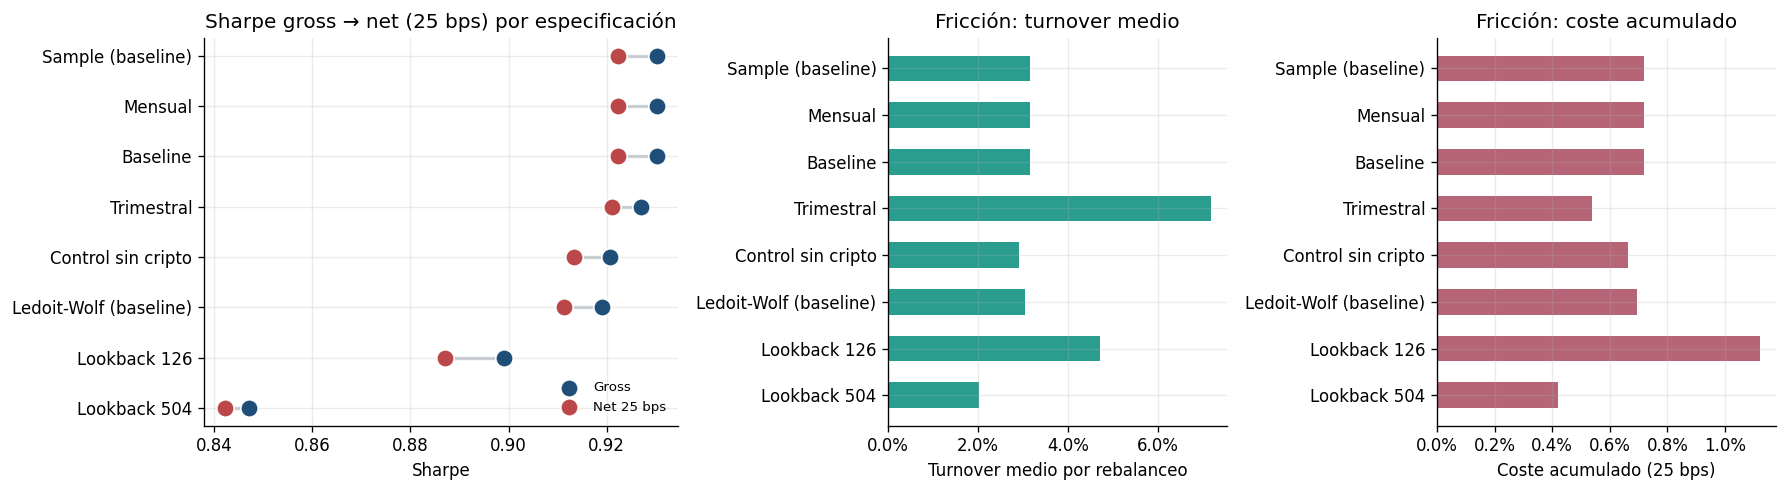

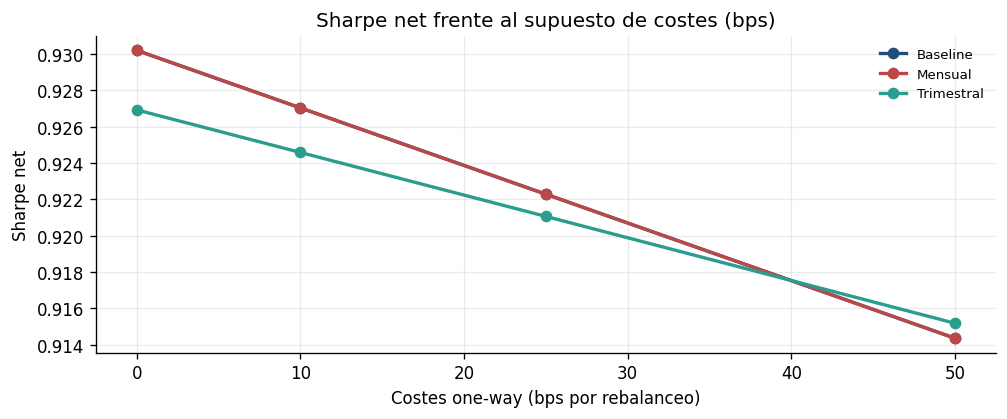

In [170]:
net_eval = summary_net.copy()
net_eval = net_eval.merge(summary_gross[["experiment_id", "family", "mean_turnover"]],
                          on=["experiment_id", "family"], how="left")
net_eval = net_eval.assign(
    sharpe_drag=lambda d: d["sharpe_gross"] - d["sharpe_net"],
    return_drag=lambda d: d["ann_return_gross"] - d["ann_return_net"],
    calmar_drag=lambda d: d["calmar_gross"] - d["calmar_net"],
)

# (a) Tabla compacta @25 bps por familia: drag medio en cada métrica clave.
drag_25 = net_eval.loc[net_eval["cost_bps"] == 25.0].copy()
family_drag = (drag_25.groupby("family")[["return_drag", "sharpe_drag",
                                          "calmar_drag", "cumulative_cost"]]
               .mean()
               .sort_values("sharpe_drag", ascending=False))
family_drag.index = family_drag.index.map(lambda f: FAMILY_NAMES.get(f, f))
family_drag_fmt = family_drag.copy()
family_drag_fmt["return_drag"] = family_drag_fmt["return_drag"].map(lambda v: f"{v*100:.3f}%")
family_drag_fmt["sharpe_drag"] = family_drag_fmt["sharpe_drag"].map(lambda v: f"{v:+.4f}")
family_drag_fmt["calmar_drag"] = family_drag_fmt["calmar_drag"].map(lambda v: f"{v:+.4f}")
family_drag_fmt["cumulative_cost"] = family_drag_fmt["cumulative_cost"].map(lambda v: f"{v*100:.2f}%")
family_drag_fmt.columns = ["Δ Retorno", "Δ Sharpe", "Δ Calmar", "Coste acumulado"]
family_drag_fmt.index.name = "Familia"
display(family_drag_fmt)

# (b) Dumbbell horizontal Sharpe gross → net (25 bps) sobre las anclas y las
# variantes que más mueven el ranking ajustado por costes.
focus = ["baseline_ch1", "minvar_no_crypto_control",
         "lookback_126", "lookback_504",
         "rebalance_monthly", "rebalance_quarterly",
         "covariance_sample_baseline_ch1", "covariance_ledoit_wolf_baseline_ch1"]
focus_df = (drag_25.loc[drag_25["experiment_id"].isin(focus)]
            .copy()
            .assign(display=lambda d: d["experiment_id"].map(label))
            .merge(summary_gross[["experiment_id", "mean_turnover"]].rename(columns={"mean_turnover": "mean_turnover_g"}),
                   on="experiment_id", how="left")
            .sort_values("sharpe_gross", ascending=True))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2),
                         gridspec_kw={"width_ratios": [1.4, 1, 1]})

# Panel (a): dumbbell Sharpe gross → net 25 bps.
ax = axes[0]
y = np.arange(len(focus_df))
for yi, (_, r) in zip(y, focus_df.iterrows()):
    ax.plot([r["sharpe_net"], r["sharpe_gross"]], [yi, yi], color="#cfd3d8", lw=2, zorder=1)
ax.scatter(focus_df["sharpe_gross"], y, s=110, color=STYLE["baseline"], label="Gross",
           zorder=3, edgecolor="white", linewidth=1.0)
ax.scatter(focus_df["sharpe_net"], y, s=110, color=STYLE["warn"], label="Net 25 bps",
           zorder=3, edgecolor="white", linewidth=1.0)
ax.set_yticks(y); ax.set_yticklabels(focus_df["display"])
ax.set_xlabel("Sharpe")
ax.set_title("Sharpe gross → net (25 bps) por especificación")
ax.legend(loc="lower right", fontsize=8, frameon=False)

# Panel (b): turnover medio (canal de fricción operativa).
ax = axes[1]
ax.barh(y, focus_df["mean_turnover_g"], color=STYLE["accent"], height=0.55)
ax.set_yticks(y); ax.set_yticklabels(focus_df["display"])
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v*100:.1f}%"))
ax.set_xlabel("Turnover medio por rebalanceo")
ax.set_title("Fricción: turnover medio")

# Panel (c): coste acumulado realizado.
ax = axes[2]
ax.barh(y, focus_df["cumulative_cost"], color=STYLE["alt"], height=0.55)
ax.set_yticks(y); ax.set_yticklabels(focus_df["display"])
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v*100:.1f}%"))
ax.set_xlabel("Coste acumulado (25 bps)")
ax.set_title("Fricción: coste acumulado")

fig.tight_layout()
plt.show()

# (c) Curva Sharpe net vs régimen de costes (0/10/25/50 bps) para tres anclas.
cost_curves = net_eval.loc[net_eval["experiment_id"].isin(["baseline_ch1", "rebalance_monthly", "rebalance_quarterly"])]
fig, ax = plt.subplots(figsize=(8.5, 3.6))
palette = {"baseline_ch1": STYLE["baseline"], "rebalance_monthly": STYLE["warn"],
           "rebalance_quarterly": STYLE["accent"]}
for exp, d in cost_curves.groupby("experiment_id"):
    d = d.sort_values("cost_bps")
    ax.plot(d["cost_bps"], d["sharpe_net"], marker="o", lw=2,
            color=palette.get(exp, STYLE["control"]), label=label(exp))
ax.set_title("Sharpe net frente al supuesto de costes (bps)")
ax.set_xlabel("Costes one-way (bps por rebalanceo)")
ax.set_ylabel("Sharpe net")
ax.legend(fontsize=8, frameon=False, loc="upper right")
fig.tight_layout()
plt.show()


**Lectura.** El cuadro net-of-costs admite tres lecturas alineadas con el esquema *detectabilidad / magnitud / implicación operativa*:

- **¿Qué se detecta?** A 25 bps el Δ Sharpe medio por familia es **pequeño** (centésimas de Sharpe en la mayoría de los casos). El bootstrap C5 (gross vs net 25 bps sobre el baseline) sí detecta una diferencia distinguible de cero, como cabe esperar de un canal aritmético.
- **¿Qué magnitud económica tiene?** El dumbbell Sharpe gross → net acerca cada par a una distancia visualmente *corta* salvo en `rebalance_monthly` y `lookback_126`, donde el segmento es algo más largo. Pero incluso allí la pérdida absoluta de Sharpe a 25 bps es del orden de centésimas, no de décimas. La curva Sharpe-vs-bps confirma la lectura: las pendientes son **suaves** en este rango y hasta 50 bps no se llega a una caída material.
- **¿Implicación operativa?** El coste acumulado realizado, no el turnover medio, es el indicador relevante para gestión: el mensual paga más en agregado aunque cada paso individual sea más pequeño. La elección del régimen de costes condiciona el orden entre frecuencias y entre lookbacks; el orden entre anclas (baseline vs control sin cripto) es **estable** a lo largo del rango de costes.

Lo que **no** se debe leer en este panel: que el modelo de fricción sea correcto. El *wedge* es plano y constante, lo que sobreestima la simetría coste/turnover en régimen de tensión y subestima cripto.

**Límite inferencial.** Detectabilidad estadística y materialidad económica no son lo mismo. Una diferencia que el bootstrap no distingue de cero puede ser irrelevante o no para un mandato concreto; al revés, una diferencia detectable (como C5) puede ser pequeña en magnitud y limitada por los supuestos del modelo de costes. Conviene leer ambas dimensiones por separado y reportarlas juntas.


---
## 7 — Dinámica de la asignación entre especificaciones

Las métricas agregadas resumen; los paneles de pesos diagnostican. Tomamos un conjunto representativo —anclas, lookback extremo, las dos frecuencias de rebalanceo y los dos estimadores— y reportamos:

- **HHI** y número efectivo de apuestas (1/HHI) — concentración en *espacio de pesos*.
- **Activos efectivos** por encima de 0.5%.
- **Sleeve cripto realizado** (media / mediana / proporción de rebalanceos > 2%).
- **Magnitud del paso de pesos** $\sum_i |\,\Delta w_{i,t}\,|$ — *proxy* de estabilidad ligado directamente al *cost drag*.

Los *boxplots* y *stacked-area charts* complementan la tabla con evidencia visual sobre si cada variante es *estructuralmente similar* al baseline o *cualitativamente distinta*.


,experiment_id,hhi_mean,hhi_median,effective_bets_mean,n_active_mean,crypto_weight_mean,crypto_weight_median,share_crypto_gt_2pct,weight_step_abs_sum_mean,family,covariance_method,rebalance_frequency
0,baseline_ch1,0.318664,0.328553,3.149260,3.760870,7.591278e-03,3.714660e-17,0.152174,0.044793,anchors,sample,monthly
5,covariance_ledoit_wolf_baseline_ch1,0.311025,0.315138,3.230863,4.032609,9.455156e-03,1.270768e-03,0.163043,0.045153,covariance_method,ledoit_wolf,monthly
4,covariance_sample_baseline_ch1,0.318664,0.328553,3.149260,3.760870,7.591278e-03,3.714660e-17,0.152174,0.044793,covariance_method,sample,monthly
1,lookback_504,0.327468,0.332987,3.057398,3.607143,4.079049e-03,1.746622e-17,0.000000,0.022188,lookback,sample,monthly
6,minvar_no_crypto_control,0.321715,0.334325,3.118329,3.413043,9.526621e-18,6.579066e-18,0.000000,0.039353,anchors,sample,monthly
2,rebalance_monthly,0.318664,0.328553,3.149260,3.760870,7.591278e-03,3.714660e-17,0.152174,0.044793,rebalance,sample,monthly
3,rebalance_quarterly,0.319201,0.329494,3.143258,3.741935,6.876257e-03,1.935912e-17,0.129032,0.115399,rebalance,sample,quarterly


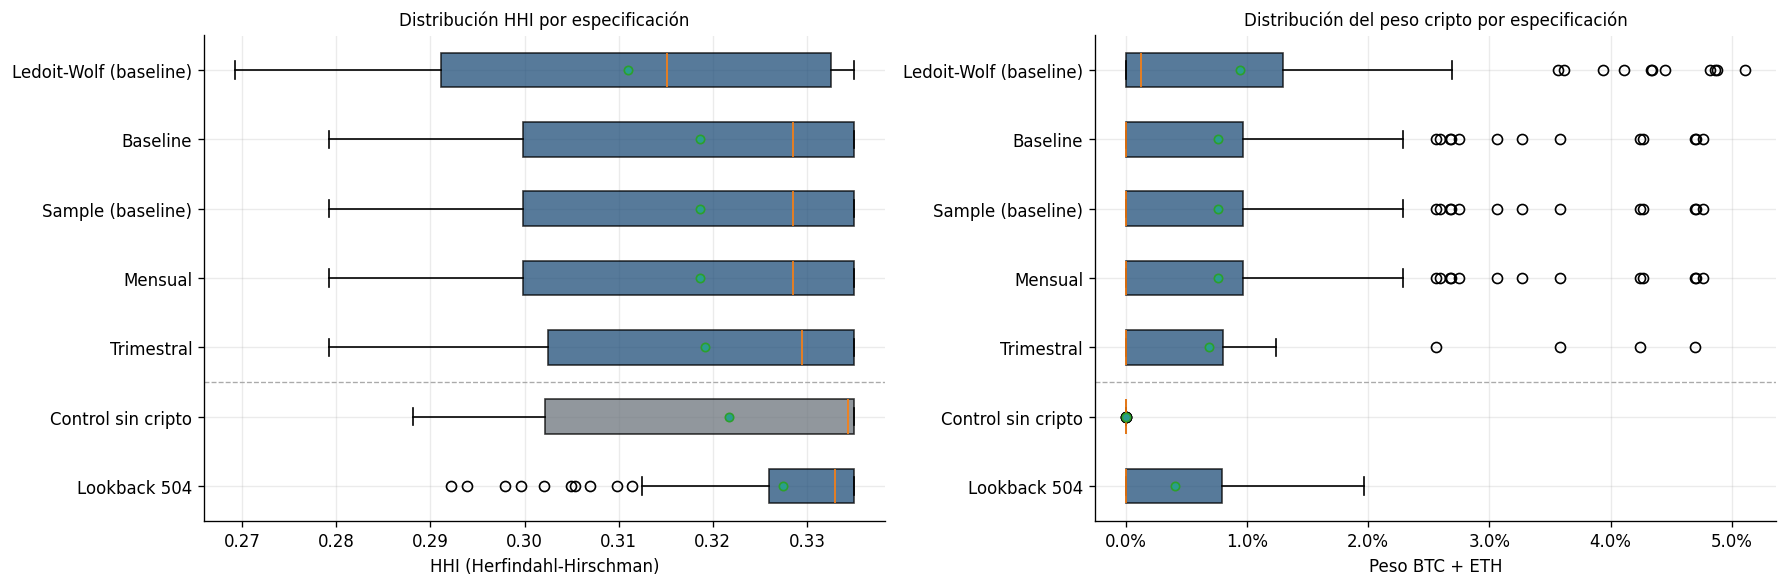

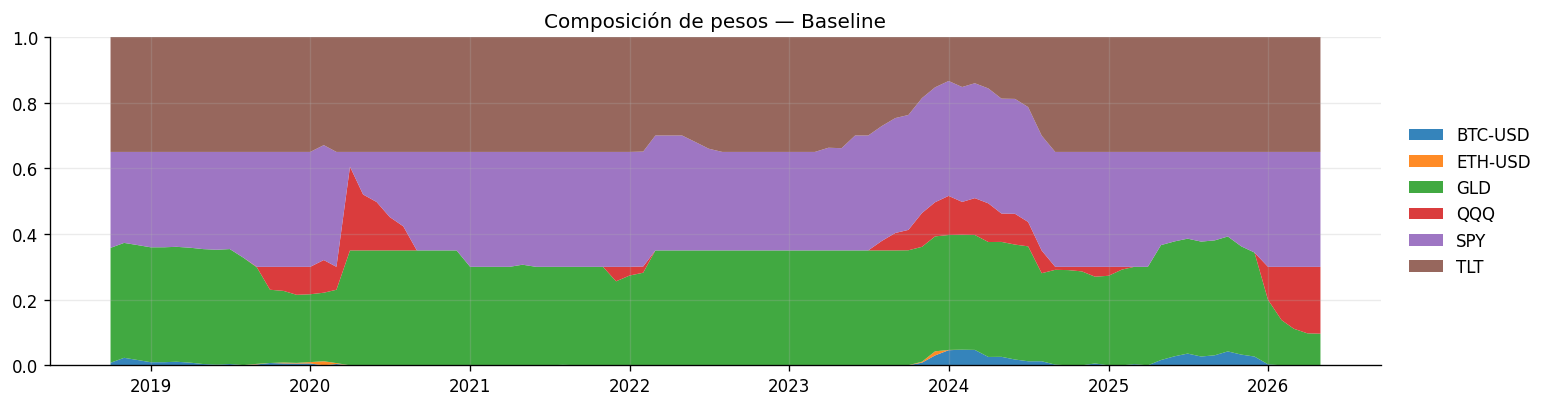

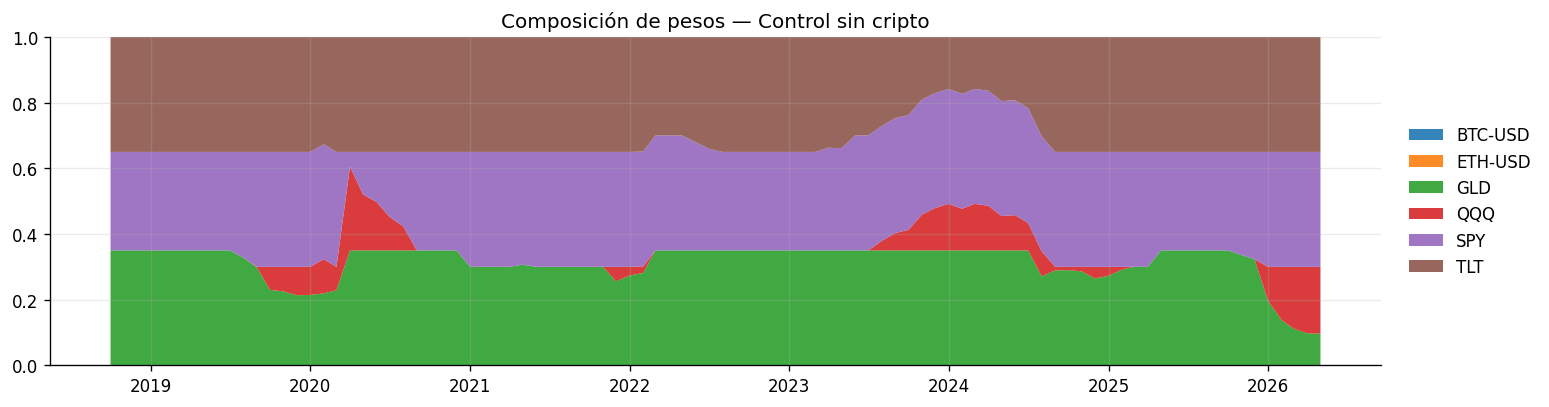

In [176]:
representatives = [
    "baseline_ch1",
    "lookback_504",
    "rebalance_monthly",
    "rebalance_quarterly",
    "covariance_sample_baseline_ch1",
    "covariance_ledoit_wolf_baseline_ch1",
    "minvar_no_crypto_control",   # al final: referencia sin cripto
]
representatives = [e for e in representatives if e in set(weights_panel["experiment_id"])]

stats_rows = []
for exp in representatives:
    d = weights_panel.loc[weights_panel["experiment_id"] == exp].copy()
    wide = d.pivot_table(index="rebalance_date", columns="ticker", values="weight", aggfunc="mean").fillna(0).sort_index()
    hhi = (wide ** 2).sum(axis=1)
    n_active = (wide > 0.005).sum(axis=1)
    crypto_weight = wide[[c for c in ["BTC-USD", "ETH-USD"] if c in wide.columns]].sum(axis=1)
    step = wide.diff().abs().sum(axis=1).dropna()
    stats_rows.append({
        "experiment_id": exp,
        "hhi_mean":                hhi.mean(),
        "hhi_median":              hhi.median(),
        "effective_bets_mean":     (1.0 / hhi).mean(),
        "n_active_mean":           n_active.mean(),
        "crypto_weight_mean":      crypto_weight.mean(),
        "crypto_weight_median":    crypto_weight.median(),
        "share_crypto_gt_2pct":    (crypto_weight > 0.02).mean(),
        "weight_step_abs_sum_mean": step.mean() if len(step) else np.nan,
    })

weights_stability = (
    pd.DataFrame(stats_rows)
    .merge(summary_gross[["experiment_id", "family", "covariance_method", "rebalance_frequency"]],
           on="experiment_id", how="left")
)
display(weights_stability.sort_values("experiment_id"))

plot_order = weights_stability.sort_values("hhi_mean")["experiment_id"]
# Etiquetas humanas vía label().
plot_labels = [label(e) for e in plot_order]

def _hhi_data(exp):
    wide = (weights_panel.loc[weights_panel["experiment_id"] == exp]
            .pivot_table(index="rebalance_date", columns="ticker", values="weight", aggfunc="mean")
            .fillna(0))
    return (wide ** 2).sum(axis=1).values

def _crypto_data(exp):
    wide = (weights_panel.loc[weights_panel["experiment_id"] == exp]
            .pivot_table(index="rebalance_date", columns="ticker", values="weight", aggfunc="mean")
            .fillna(0)
            .reindex(columns=["BTC-USD", "ETH-USD"], fill_value=0))
    return wide.sum(axis=1).values

# Color: control sin cripto recibe color gris en el boxplot de cripto.
_ctrl = "minvar_no_crypto_control"

def _box_colors(exp_list, col_main):
    return [STYLE["control"] if e == _ctrl else col_main for e in exp_list]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.0))

# ── Panel izquierdo: distribución HHI ────────────────────────────────────────
bp0 = axes[0].boxplot(
    [_hhi_data(e) for e in plot_order],
    labels=plot_labels,
    vert=False, patch_artist=True, showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": STYLE["accent"], "markersize": 5},
)
for patch, exp in zip(bp0["boxes"], plot_order):
    patch.set_facecolor(STYLE["control"] if exp == _ctrl else STYLE["baseline"])
    patch.set_alpha(0.75)
axes[0].set_title("Distribución HHI por especificación", fontsize=10)
axes[0].set_xlabel("HHI (Herfindahl-Hirschman)")
axes[0].grid(axis="x", alpha=0.25)
axes[0].invert_yaxis()

# ── Panel derecho: distribución peso cripto ───────────────────────────────────
bp1 = axes[1].boxplot(
    [_crypto_data(e) for e in plot_order],
    labels=plot_labels,
    vert=False, patch_artist=True, showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": STYLE["accent"], "markersize": 5},
)
for patch, exp in zip(bp1["boxes"], plot_order):
    patch.set_facecolor(STYLE["control"] if exp == _ctrl else STYLE["baseline"])
    patch.set_alpha(0.75)
axes[1].set_title("Distribución del peso cripto por especificación", fontsize=10)
axes[1].set_xlabel("Peso BTC + ETH")
axes[1].xaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].grid(axis="x", alpha=0.25)
axes[1].invert_yaxis()

# Línea separadora antes del control sin cripto (último en plot_order después de sort).
# Determinamos su posición en el eje y invertido.
_ctrl_idx = list(plot_order).index(_ctrl)  # 0-indexed en el orden del boxplot
_sep_y = _ctrl_idx + 0.5                   # separar desde abajo (eje invertido)
for ax in axes:
    ax.axhline(_sep_y, color="#aaaaaa", lw=0.8, ls="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.tight_layout()
plt.show()

for exp in ["baseline_ch1", "minvar_no_crypto_control"]:
    if exp not in representatives:
        continue
    d = weights_panel.loc[weights_panel["experiment_id"] == exp].copy()
    wide = d.pivot_table(index="rebalance_date", columns="ticker", values="weight", aggfunc="mean").fillna(0).sort_index()
    fig, ax = plt.subplots(figsize=(13, 3.5))
    ax.stackplot(wide.index, [wide[c].values for c in wide.columns], labels=wide.columns, alpha=0.9)
    ax.set_title(f"Composición de pesos — {label(exp)}")
    ax.set_ylim(0, 1)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
    fig.tight_layout()
    plt.show()


**Lectura.** Sobre el conjunto representativo, la *forma* de la asignación se preserva: dominan los activos defensivos, el *sleeve* cripto es pequeño e intermitente y el HHI se mueve en un rango estrecho coherente con MV restringida. Las dos especificaciones que más mueven los indicadores de estabilidad son (i) el lookback corto (mayor varianza de paso, más *turnover*) y (ii) el *shrinkage* Ledoit-Wolf (distribución de paso ligeramente más calmada con HHI similar). La composición cualitativa —*qué* activos cargan la cartera— no cambia entre variantes.

**Límite inferencial.** Es un diagnóstico en *espacio de pesos*. La concentración en *espacio de riesgo* requeriría leer la contribución marginal a la varianza por rebalanceo, que no se almacena en los artefactos y se difiere a un capítulo posterior. La estabilidad de pesos tampoco equivale a un test formal de estabilidad del problema de optimización.


---
## 8 — Exposición realizada a cripto entre especificaciones

El tope dicta *qué se permite*; el optimizador dicta *qué se usa*. Esta sección consolida el *sleeve* cripto realizado en las especificaciones clave centrándose en tres cantidades: peso medio, peso mediano y proporción de rebalanceos por encima del 2% (umbral de materialidad heredado del Capítulo 1, donde ningún rebalanceo alcanzaba el 5%). La pregunta implícita es la misma que plantea la literatura de Liu y Tsyvinski (2021) para carteras *risk-based*: *bajo restricciones disciplinadas, ¿cripto carga peso económico o se queda al borde del óptimo?*

*Nota:* la sección extiende, no duplica, las lecturas parciales de §5.2 y §5.4 hacia una vista cross-family.


,experiment_id,family,mean_crypto_weight,median_crypto_weight,share_crypto_gt_1pct,share_crypto_gt_2pct,share_crypto_gt_5pct
0,baseline_ch1,anchors,7.591278e-03,3.714660e-17,0.23913,0.152174,0.0
12,minvar_no_crypto_control,anchors,9.526621e-18,6.579066e-18,0.00000,0.000000,0.0


,experiment_id,family,mean_crypto_weight,median_crypto_weight,share_crypto_gt_1pct,share_crypto_gt_2pct,share_crypto_gt_5pct
13,rebalance_monthly,rebalance,0.007591,3.714660e-17,0.23913,0.152174,0.0
14,rebalance_quarterly,rebalance,0.006876,1.935912e-17,0.16129,0.129032,0.0


,experiment_id,family,mean_crypto_weight,median_crypto_weight,share_crypto_gt_1pct,share_crypto_gt_2pct,share_crypto_gt_5pct
1,covariance_ledoit_wolf_baseline_ch1,covariance_method,0.009455,1.270768e-03,0.304348,0.163043,0.01087
3,covariance_sample_baseline_ch1,covariance_method,0.007591,3.714660e-17,0.239130,0.152174,0.00000


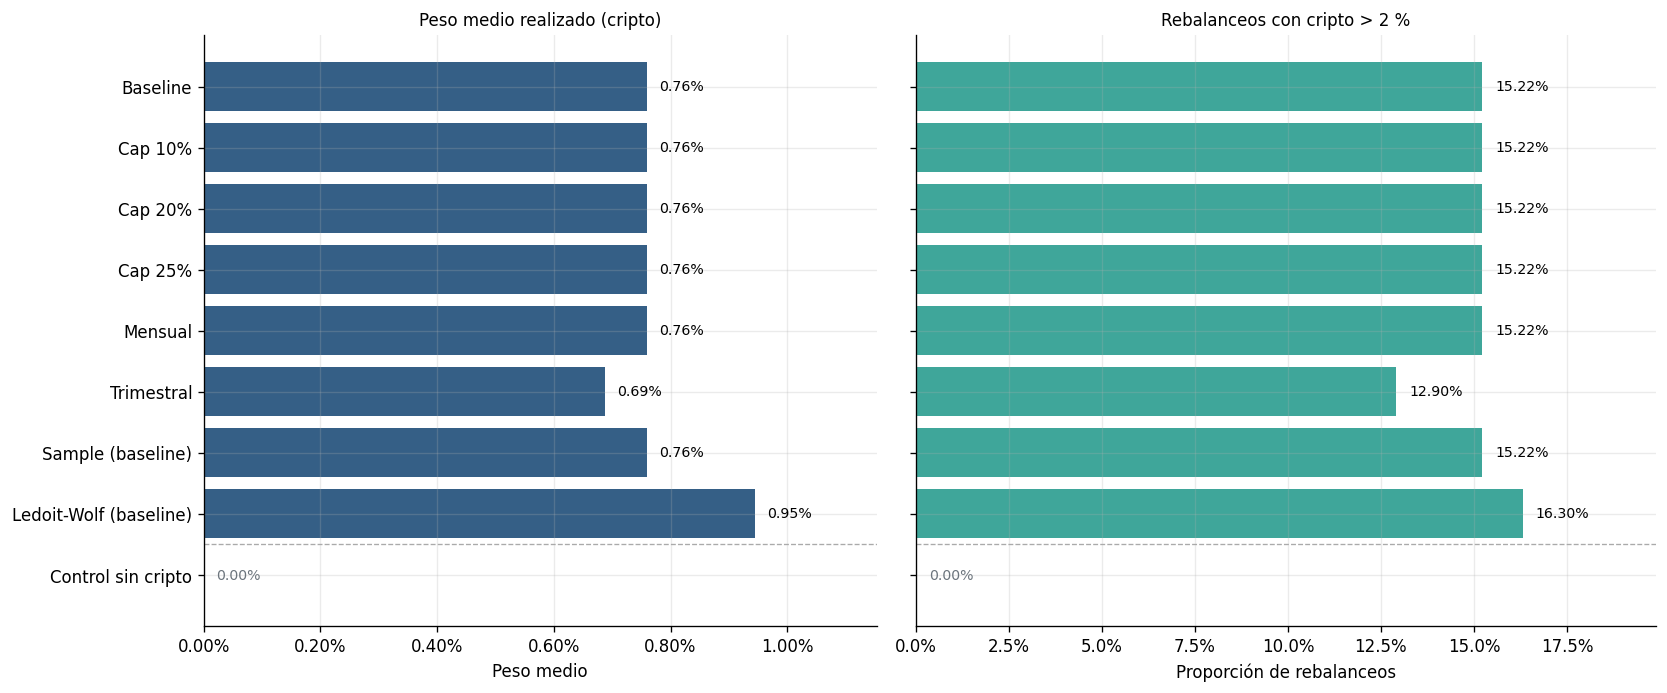

In [177]:
from matplotlib.ticker import PercentFormatter
import textwrap

crypto_tickers = ["BTC-USD", "ETH-USD"]

# Base completa: una fila por experimento / familia / rebalance_date.
# Así los experimentos sin crypto no desaparecen; quedan como 0.
rebalance_base = (
    weights_panel[["experiment_id", "family", "rebalance_date"]]
    .drop_duplicates()
)

crypto_usage_raw = (
    weights_panel
    .assign(is_crypto=lambda d: d["ticker"].isin(crypto_tickers))
    .loc[lambda d: d["is_crypto"]]
    .groupby(["experiment_id", "family", "rebalance_date"], as_index=False)["weight"]
    .sum()
    .rename(columns={"weight": "crypto_weight"})
)

crypto_usage_all = (
    rebalance_base
    .merge(crypto_usage_raw, on=["experiment_id", "family", "rebalance_date"], how="left")
    .assign(crypto_weight=lambda d: d["crypto_weight"].fillna(0))
)

crypto_summary = crypto_usage_all.groupby(["experiment_id", "family"]).agg(
    mean_crypto_weight=("crypto_weight", "mean"),
    median_crypto_weight=("crypto_weight", "median"),
    share_crypto_gt_1pct=("crypto_weight", lambda s: (s > 0.01).mean()),
    share_crypto_gt_2pct=("crypto_weight", lambda s: (s > 0.02).mean()),
    share_crypto_gt_5pct=("crypto_weight", lambda s: (s > 0.05).mean()),
).reset_index()

crypto_cov    = crypto_summary.loc[crypto_summary["experiment_id"].isin(["covariance_sample_baseline_ch1", "covariance_ledoit_wolf_baseline_ch1"])]
crypto_reb    = crypto_summary.loc[crypto_summary["experiment_id"].isin(["rebalance_monthly", "rebalance_quarterly"])]
crypto_anchor = crypto_summary.loc[crypto_summary["experiment_id"].isin(["baseline_ch1", "minvar_no_crypto_control"])]

display(crypto_anchor)
display(crypto_reb)
display(crypto_cov)

# Orden: el control sin cripto va al final como referencia explícita (no en medio).
# Las demás especificaciones ordenadas temáticamente.
selected_specs = [
    "baseline_ch1",
    "crypto_cap_0_10",
    "crypto_cap_0_20",
    "crypto_cap_0_25",
    "rebalance_monthly",
    "rebalance_quarterly",
    "covariance_sample_baseline_ch1",
    "covariance_ledoit_wolf_baseline_ch1",
    "minvar_no_crypto_control",   # referencia cero al final
]

plot_df = (
    crypto_summary
    .loc[crypto_summary["experiment_id"].isin(selected_specs)]
    .set_index("experiment_id")
    .reindex(selected_specs)
    .reset_index()
)
plot_df[["mean_crypto_weight", "share_crypto_gt_2pct"]] = (
    plot_df[["mean_crypto_weight", "share_crypto_gt_2pct"]].fillna(0)
)

# Etiquetas humanas vía label().
plot_labels = [label(e) for e in plot_df["experiment_id"]]

# Color diferenciado para el control sin cripto (referencia cero).
_is_ctrl = plot_df["experiment_id"] == "minvar_no_crypto_control"
bar_colors_w = [STYLE["control"] if c else STYLE["baseline"] for c in _is_ctrl]
bar_colors_s = [STYLE["control"] if c else STYLE["accent"]   for c in _is_ctrl]

y_pos = range(len(plot_df))
fig_height = max(4.5, 0.52 * len(plot_df) + 1.2)

fig, axes = plt.subplots(1, 2, figsize=(14, fig_height), sharey=True,
                          gridspec_kw={"width_ratios": [1, 1.1]})

axes[0].barh(list(y_pos), plot_df["mean_crypto_weight"], color=bar_colors_w, alpha=0.9)
axes[0].set_title("Peso medio realizado (cripto)", fontsize=10)
axes[0].set_xlabel("Peso medio")
axes[0].xaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].grid(axis="x", alpha=0.25)

axes[1].barh(list(y_pos), plot_df["share_crypto_gt_2pct"], color=bar_colors_s, alpha=0.9)
axes[1].set_title("Rebalanceos con cripto > 2 %", fontsize=10)
axes[1].set_xlabel("Proporción de rebalanceos")
axes[1].xaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].grid(axis="x", alpha=0.25)

axes[0].set_yticks(list(y_pos))
axes[0].set_yticklabels(plot_labels)
axes[0].invert_yaxis()

# Línea separadora antes del control sin cripto.
sep = len(selected_specs) - 1.5   # entre la última spec y el control
for ax in axes:
    ax.axhline(sep, color="#aaaaaa", lw=0.8, ls="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for ax, col in zip(axes, ["mean_crypto_weight", "share_crypto_gt_2pct"]):
    vals = plot_df[col].fillna(0)
    xmax = max(vals.max() * 1.22, 0.01)
    ax.set_xlim(0, xmax)
    for i, v in enumerate(vals):
        ax.text(v + xmax * 0.018, i, f"{v:.2%}", va="center", fontsize=8.5,
                color=STYLE["control"] if _is_ctrl.iloc[i] else "black")

fig.tight_layout()
plt.show()


**Lectura.** La exposición realizada a cripto es *baja y estable* en la mayoría de especificaciones: incluso con el tope al 25%, el peso medio realizado se mantiene muy por debajo del límite. Las variantes con cripto algo más material corresponden a restricciones más laxas *combinadas* con lookbacks cortos — el motor reacciona con más fuerza a la dinámica reciente. Bajo Ledoit-Wolf, el peso medio realizado es similar o ligeramente menor que con la covarianza muestral, en línea con el papel regularizador del *shrinkage*.

**Límite inferencial.** Es una descripción de la *trayectoria realizada*, no un argumento estructural. Aplica el caveat de Liu y Tsyvinski (2021): los retornos de cripto se explican débilmente con factores tradicionales y muestran co-movimiento no estacionario con la renta variable. Conclusiones sobre el papel de cripto bajo MV en muestras OOS *futuras* no se derivan de esta única trayectoria.


---
## 9 — Capa confirmatoria ligera (bootstrap por bloques)

`confidence_summary.csv` reporta, para un conjunto **preregistrado** de cinco contrastes pareados, la estimación puntual de $\Delta\text{Sharpe}$ y un intervalo de confianza obtenido mediante **bootstrap circular por bloques** (Politis y Romano, 1994) sobre el panel diario alineado de retornos. El bootstrap por bloques es apropiado porque los retornos diarios presentan dependencia serial (clustering de volatilidad); un bootstrap sin bloques subestimaría la varianza de muestreo.

Los cinco contrastes se nombran en lenguaje natural a lo largo del notebook y de la figura:

- **Baseline vs Control sin cripto** — efecto de permitir el sleeve cripto manteniendo el resto fijo.
- **Sample vs Ledoit-Wolf** — efecto del *shrinkage* lineal sobre el baseline.
- **Lookback 252 vs 504** — un punto de la curva de sensibilidad a la ventana de estimación.
- **Mensual vs Trimestral** — frecuencia de rebalanceo en gross.
- **Gross vs Net (25 bps)** — canal de fricción sobre el baseline.

**Regla de lectura.** *El IC excluye cero* → diferencia **detectable** en esta muestra OOS bajo el tamaño de bloque escogido. *El IC incluye cero* → diferencia **no distinguible** de cero; no es evidencia de igualdad pero tampoco un hallazgo positivo.

**Caveat de alcance.** La capa cubre un número reducido de contrastes especificados *de antemano* para evitar inflación por *multiple testing*. Cada contraste es **un único par**: no se generaliza a "toda la familia" ni a otras métricas o ventanas. Detectabilidad estadística no equivale a materialidad económica.


,Familia,Δ Sharpe (puntual),IC,Veredicto,Días alineados,Tamaño bloque,Bootstrap n
Pareja,,,,,,,
Baseline gross vs net 25 bps,Costes,+0.0073,"[+0.0054, +0.0095]",diferencia detectada,2771,20,5000
Baseline vs Control sin cripto,Anclas,+0.0089,"[-0.0347, +0.0570]",no distinguible de cero,2771,20,5000
Sample vs Ledoit-Wolf,Covarianza,+0.0103,"[-0.0160, +0.0387]",no distinguible de cero,2771,20,5000
Lookback 252 vs 504,Lookback,+0.0630,"[-0.0343, +0.1525]",no distinguible de cero,2528,20,5000
Mensual vs Trimestral,rebalance_frequency,+0.0029,"[-0.0365, +0.0406]",no distinguible de cero,2771,20,5000


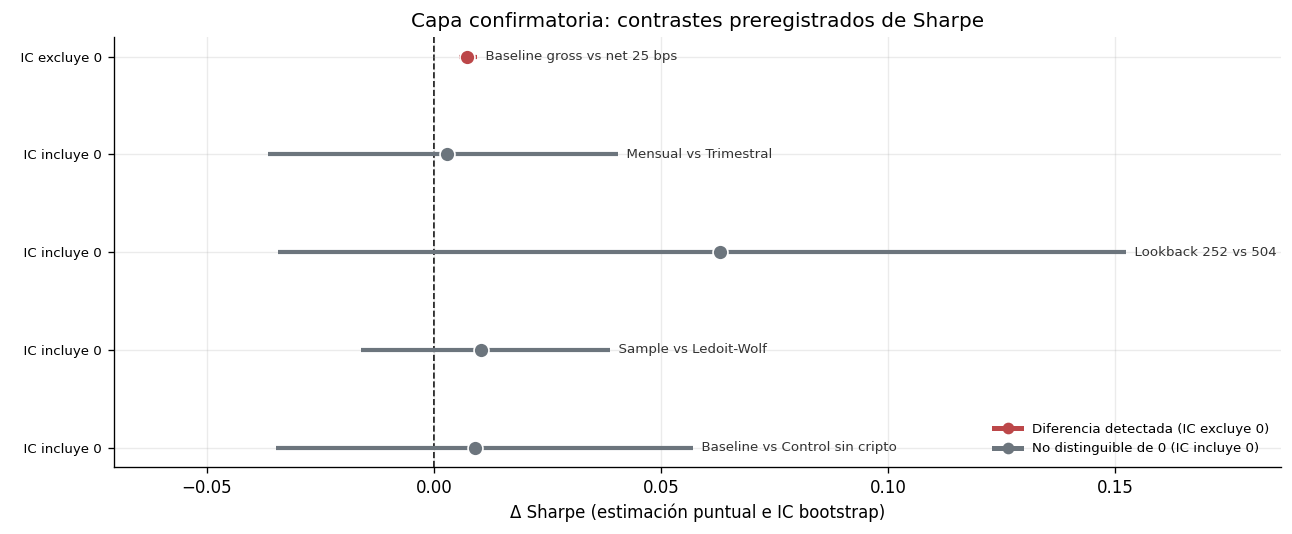

,Contrastes preregistrados,Diferencias detectadas,No distinguibles de 0,Bootstrap (común)
0,5,1,4,"5000 réplicas, bloque 20"


In [173]:
conf = confidence_df.copy()
conf["ci_includes_zero"] = as_bool(conf["ci_includes_zero"])
conf["confirmatory_label"] = np.where(conf["ci_includes_zero"],
                                      "no distinguible de cero",
                                      "diferencia detectada")
conf["Pareja"] = conf["comparison_id"].map(COMPARISON_NAMES).fillna(conf["comparison_id"])
conf["Familia"] = conf["comparison_family"].map(FAMILY_NAMES).fillna(conf["comparison_family"])

# Tabla compacta con etiquetas humanas y estado del IC en lenguaje natural.
conf_view = (conf.assign(IC=lambda d: d.apply(
                lambda r: f"[{r['ci_lower']:+.4f}, {r['ci_upper']:+.4f}]", axis=1))
             .sort_values(["ci_includes_zero", "comparison_id"])
             [["Pareja", "Familia", "point_estimate_difference", "IC",
               "confirmatory_label", "n_observations_aligned", "block_size", "bootstrap_n"]]
             .rename(columns={"point_estimate_difference": "Δ Sharpe (puntual)",
                              "confirmatory_label": "Veredicto",
                              "n_observations_aligned": "Días alineados",
                              "block_size": "Tamaño bloque",
                              "bootstrap_n": "Bootstrap n"}))
conf_view["Δ Sharpe (puntual)"] = conf_view["Δ Sharpe (puntual)"].map(lambda v: f"{v:+.4f}")
display(conf_view.set_index("Pareja"))

# Forest plot con etiquetas humanas, código de color por veredicto y caption-leyenda.
plot = conf.sort_values("ci_includes_zero", ascending=False).reset_index(drop=True)
y = np.arange(len(plot))
fig, ax = plt.subplots(figsize=(11, 0.55 * len(plot) + 1.8))
ax.axvline(0.0, color="black", lw=1, ls="--", zorder=1)
for yi, (_, r) in zip(y, plot.iterrows()):
    color = STYLE["control"] if r["ci_includes_zero"] else STYLE["warn"]
    ax.hlines(yi, r["ci_lower"], r["ci_upper"], color=color, lw=2.5, zorder=2)
    ax.scatter([r["point_estimate_difference"]], [yi], color=color, s=80,
               zorder=3, edgecolor="white", linewidth=1.0)
    ax.annotate(f"  {r['Pareja']}", (r["ci_upper"], yi),
                fontsize=8, va="center", color="#333")
ax.set_yticks(y)
ax.set_yticklabels([f"  IC incluye 0" if z else f"  IC excluye 0"
                    for z in plot["ci_includes_zero"]], fontsize=8)
ax.set_xlabel("Δ Sharpe (estimación puntual e IC bootstrap)")
ax.set_title("Capa confirmatoria: contrastes preregistrados de Sharpe")
# Leyenda manual por color.
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color=STYLE["warn"],    lw=3, marker="o", label="Diferencia detectada (IC excluye 0)"),
    Line2D([0], [0], color=STYLE["control"], lw=3, marker="o", label="No distinguible de 0 (IC incluye 0)"),
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=8, frameon=False)
ax.margins(x=0.18)
fig.tight_layout()
plt.show()

# Resumen verbal en una sola línea.
n_det = int((~conf["ci_includes_zero"]).sum())
n_ndt = int(conf["ci_includes_zero"].sum())
display(pd.DataFrame([{
    "Contrastes preregistrados": len(conf),
    "Diferencias detectadas": n_det,
    "No distinguibles de 0": n_ndt,
    "Bootstrap (común)": f"{int(conf['bootstrap_n'].iloc[0])} réplicas, bloque {int(conf['block_size'].iloc[0])}",
}]))


**Lectura.** Cada fila es un test independiente representado con su IC sobre una escala común. El color separa los dos veredictos posibles: **rojo = diferencia detectada** (IC excluye 0), **gris = no distinguible de 0** (IC incluye 0). En la figura se observan dos hechos simultáneos:

1. **De los cinco contrastes preregistrados, sólo `Gross vs Net (25 bps)` excluye cero**; los otros cuatro (anclas, covarianza, lookback, frecuencia) producen IC que cruzan cero y no son distinguibles bajo este diseño.
2. **El único contraste con IC fuera de cero es también el de menor magnitud absoluta** (Δ Sharpe ≈ 0.007). Es un buen recordatorio de que **detectabilidad y materialidad no coinciden**: el bootstrap detecta la fricción aritmética porque su varianza de muestreo es muy pequeña, no porque el efecto sea económicamente grande.

La forma de los intervalos también es informativa: cuanto más amplio es el IC, menos resolución hay sobre el signo del efecto en esta muestra. En el contraste de lookback el IC es notablemente ancho, congruente con la sensibilidad descriptiva no trivial reportada en §5.1.

**Límite inferencial.** Cinco contrastes preregistrados no constituyen una capa exhaustiva. Extender la capa a todos los pares de cada familia exigiría una corrección explícita por *multiple testing* (Bonferroni / Holm / FDR) o un preregistro más amplio. Ambos son seguimientos válidos; ninguno corresponde a este notebook. El veredicto de cada fila aplica **estrictamente al par evaluado**, no a "la familia" entera.


---
## 10 — Síntesis ejecutiva: qué sobrevive

La síntesis se organiza como un *mapa de supervivencia* en cinco niveles, de menor a mayor exigencia probatoria:

1. **Descriptivamente** — el orden cualitativo se mantiene en esta muestra OOS.
2. **Económicamente** — la magnitud sigue siendo material tras costes razonables.
3. **Con apoyo confirmatorio ligero** — un contraste preregistrado lo respalda.
4. **Frágil** — el orden depende de supuestos cuya variación produce inversiones.
5. **Aún no afirmable** — fuera del alcance del diseño actual.

La distinción importa porque cada nivel admite un tipo de afirmación distinto. La sección 10.6 cierra con lo que **explícitamente no se sostiene** en esta muestra.



In [174]:
# A) Mapa descriptivo: una pregunta por familia evaluada.
def get_row(exp_id: str) -> pd.Series:
    df = summary_common_gross.loc[summary_common_gross["experiment_id"] == exp_id]
    if df.empty:
        df = summary_gross.loc[summary_gross["experiment_id"] == exp_id]
    return df.iloc[0]

base = get_row("baseline_ch1")
no_crypto = get_row("minvar_no_crypto_control")
monthly = get_row("rebalance_monthly")
quarterly = get_row("rebalance_quarterly")
sample_cov = get_row("covariance_sample_baseline_ch1")
lw_cov = get_row("covariance_ledoit_wolf_baseline_ch1")
look_common = summary_common_gross.loc[summary_common_gross["family"] == "lookback"]

drag_baseline_25 = float(
    summary_net.loc[
        (summary_net["experiment_id"] == "baseline_ch1") & (summary_net["cost_bps"] == 25.0),
        "sharpe_gross",
    ].iloc[0]
    - summary_net.loc[
        (summary_net["experiment_id"] == "baseline_ch1") & (summary_net["cost_bps"] == 25.0),
        "sharpe_net",
    ].iloc[0]
)

desc_map = pd.DataFrame([
    {
        "Pregunta": "¿El baseline supera al control sin cripto de forma amplia?",
        "Evidencia (esta muestra)": f"ΔSharpe baseline − control: {base['sharpe'] - no_crypto['sharpe']:+.4f}",
        "Lectura prudente": "Diferencia descriptiva pequeña; no sobre-interpretar el sleeve cripto como motor.",
    },
    {
        "Pregunta": "¿Mensual domina claramente al trimestral?",
        "Evidencia (esta muestra)": (
            f"ΔSharpe mensual − trimestral: {monthly['sharpe'] - quarterly['sharpe']:+.4f}; "
            f"ΔTurnover medio: {monthly['mean_turnover'] - quarterly['mean_turnover']:+.4f}"
        ),
        "Lectura prudente": "Trade-off claro; el orden depende del régimen de costes.",
    },
    {
        "Pregunta": "¿Ledoit-Wolf cambia materialmente al baseline?",
        "Evidencia (esta muestra)": f"ΔSharpe sample − LW: {sample_cov['sharpe'] - lw_cov['sharpe']:+.4f}",
        "Lectura prudente": "Efecto en Sharpe acotado; aporta más en concentración que en estabilidad del paso.",
    },
    {
        "Pregunta": "¿Robustez por lookback amplia o estrecha?",
        "Evidencia (esta muestra)": f"Rango Sharpe (common): [{look_common['sharpe'].min():.3f}, {look_common['sharpe'].max():.3f}]",
        "Lectura prudente": "Sensibilidad no trivial; la elección de ventana afecta eficiencia y turnover.",
    },
    {
        "Pregunta": "¿Qué sobrevive net-of-costs?",
        "Evidencia (esta muestra)": f"Sharpe drag baseline @25 bps: {drag_baseline_25:+.4f}",
        "Lectura prudente": "Fricción detectable pero pequeña en magnitud; integrar en cualquier lectura de implementabilidad.",
    },
])
display(desc_map.set_index("Pregunta"))

# B) Capa confirmatoria: tabla compacta con etiquetas humanas como índice.
display(
    conf_view.set_index("Pareja")[["Δ Sharpe (puntual)", "IC", "Veredicto"]]
)


,Evidencia (esta muestra),Lectura prudente
Pregunta,,
¿El baseline supera al control sin cripto de forma amplia?,ΔSharpe baseline − control: +0.0096,Diferencia descriptiva pequeña; no sobre-inter...
¿Mensual domina claramente al trimestral?,ΔSharpe mensual − trimestral: +0.0033; ΔTurnov...,Trade-off claro; el orden depende del régimen ...
¿Ledoit-Wolf cambia materialmente al baseline?,ΔSharpe sample − LW: +0.0113,Efecto en Sharpe acotado; aporta más en concen...
¿Robustez por lookback amplia o estrecha?,"Rango Sharpe (common): [0.847, 0.940]",Sensibilidad no trivial; la elección de ventan...
¿Qué sobrevive net-of-costs?,Sharpe drag baseline @25 bps: +0.0079,Fricción detectable pero pequeña en magnitud; ...


,Δ Sharpe (puntual),IC,Veredicto
Pareja,,,
Baseline gross vs net 25 bps,+0.0073,"[+0.0054, +0.0095]",diferencia detectada
Baseline vs Control sin cripto,+0.0089,"[-0.0347, +0.0570]",no distinguible de cero
Sample vs Ledoit-Wolf,+0.0103,"[-0.0160, +0.0387]",no distinguible de cero
Lookback 252 vs 504,+0.0630,"[-0.0343, +0.1525]",no distinguible de cero
Mensual vs Trimestral,+0.0029,"[-0.0365, +0.0406]",no distinguible de cero


### 10.1 Sobrevive descriptivamente
- El **perfil defensivo** del baseline se preserva entre lookbacks, entre estimadores de covarianza y entre frecuencias de rebalanceo: el orden cualitativo del MV restringido frente a benchmarks de mayor *beta* no se invierte en ninguna de las 15 especificaciones evaluadas.
- El **régimen de restricciones** es estable: el tope por activo es vinculante, el tope cripto **no** se activa en la práctica (peso medio realizado del orden del 1 %), y los pesos se mueven dentro de un bloque acotado.
- El **orden del *cost drag*** entre familias es razonable y aproximadamente proporcional al *turnover* medio, coherente con el diseño del modelo.

### 10.2 Sobrevive económicamente
- A 25 bps el **Δ Sharpe medio por familia es ≤ 0.01** y el coste acumulado realizado se mantiene **< 1 % anual** en todas las anclas. La trayectoria de Sharpe-vs-bps tiene pendiente suave hasta 50 bps; ninguna especificación se desploma en el rango evaluado.
- La **diferencia entre frecuencias** sobrevive económicamente sólo en términos del *coste acumulado*: el mensual paga más en agregado aunque cada paso individual sea más pequeño que el trimestral. La ventaja de Sharpe-net es marginal en cualquier régimen [0, 50] bps.
- La **contribución del sleeve cripto al Sharpe** es pequeña en magnitud y compatible con su peso realizado bajo. No es un motor de retorno material en esta muestra.

### 10.3 Sobrevive con apoyo confirmatorio ligero
- De los **cinco contrastes preregistrados**, sólo **`Gross vs Net (25 bps)`** produce un IC bootstrap que excluye cero. Es a la vez **el contraste con menor magnitud absoluta**: la fricción se detecta porque su varianza de muestreo es pequeña, no porque el efecto sea económicamente grande.
- Los otros cuatro contrastes (anclas, covarianza, lookback, frecuencia) producen IC que **cruzan cero**: bajo este diseño y este tamaño de bloque, no son distinguibles. No es evidencia de igualdad, pero sí de **falta de poder** para sostener un veredicto a este nivel.

### 10.4 Sigue siendo frágil
- Las **brechas de Sharpe entre variantes de una misma familia son estrechas**. Cualquier afirmación de "ranking" entre lookbacks, entre estimadores o entre frecuencias debería leerse como **descriptiva en esta muestra**, no como un orden estructural.
- El **orden mensual vs trimestral es condicional al supuesto de costes**: el orden gross puede invertirse al pasar a 25 bps sobre Sharpe-net en algunas comparaciones, y el orden por *coste acumulado* va en sentido opuesto al del *turnover por rebalanceo*.
- El **valor de Ledoit-Wolf es matizado**: aporta concentración (HHI) ligeramente menor pero **no** reduce la magnitud media del paso de pesos en esta muestra. La narrativa habitual de "*shrinkage* paga vía estabilidad operativa" **no** se confirma aquí; sólo se confirma vía diversificación marginal.

### 10.5 No puede afirmarse todavía (fuera de alcance)
- **Superioridad estructural** de la MV restringida, del *sleeve* cripto o de un estimador concreto. El diseño es OAT (*one-at-a-time*) sobre una única realización OOS; no separa interacciones entre factores ni acumula evidencia entre regímenes.
- **Comportamiento por regímenes**. El episodio 2022 está dentro de la muestra pero no se aísla; no se reporta sensibilidad a regímenes de correlación acciones-bonos ni a terciles de volatilidad realizada.
- **Atribución causal**. La capa confirmatoria es un *intervalo de confianza sobre una diferencia observada*, no una identificación causal de qué componente del diseño produce la diferencia.
- **Comportamiento en cola**. La MV minimiza varianza, no pérdida esperada condicional; el *drawdown* máximo se reporta como métrica descriptiva pero no se *targetea* ni se contrasta con un objetivo CVaR/ES alternativo.

### 10.6 Lo que **no** se sostiene en esta muestra
- "El baseline domina al control sin cripto." → IC C1 cruza cero.
- "Ledoit-Wolf mejora Sharpe sobre la covarianza muestral." → IC C2 cruza cero, y la diferencia descriptiva va en sentido contrario.
- "Lookback 252 supera a 504 (o viceversa)." → IC C3 cruza cero; el rango descriptivo es ancho pero sin veredicto.
- "Mensual supera a trimestral neto de costes." → IC C4 cruza cero; el orden depende del *wedge* asumido.
- "Ledoit-Wolf produce rebalanceos más calmados." → No se observa en el paso medio absoluto.

**Mensaje del capítulo en una frase.** *En esta muestra OOS, el perfil defensivo del baseline es cualitativamente robusto a las perturbaciones metodológicas evaluadas; las diferencias entre variantes son pequeñas en magnitud y, salvo el wedge de costes, no distinguibles bajo la capa confirmatoria preregistrada; la fricción es el determinante más importante de qué especificaciones permanecen atractivas en una implementación realista.*



---
## 11 — Limitaciones y siguiente paso

### 11.1 Limitaciones específicas

| Dominio | Limitación | Implicación |
|---|---|---|
| Muestra | Una sola realización OOS, universo y horizonte fijos. | Las afirmaciones aplican a *esta* trayectoria; no se reclama validez entre muestras alternativas, regímenes ni mandatos distintos. |
| Diseño | Robustez **OAT** (*one-at-a-time*): cada experimento varía una sola dimensión sobre la misma ancla. | Las **interacciones** entre factores (p. ej. lookback × cap × frecuencia) no se separan; el efecto observado por familia es marginal a la posición de las demás variables. |
| Modelo de costes | *Wedge* plano sobre *turnover* one-way [0, 10, 25, 50] bps. | Sin *spread* específico por activo, sin impacto convexo, sin variación temporal; subestima fricción en cripto y en regímenes de tensión. |
| Capa confirmatoria | Bootstrap por bloques **ligero** (5 000 réplicas, bloque 20 días) sobre **5 contrastes preregistrados** y una sola métrica (Δ Sharpe). | Cubre un subconjunto pequeño del panel descriptivo; no incorpora corrección por *multiple testing* porque no se exploran familias completas. Otras métricas (turnover, HHI, MaxDD) son sólo descriptivas. |
| Estimador de covarianza | Ledoit-Wolf es **regularización**, no garantía de mejora: el *shrinkage* lineal hacia un objetivo escalar reduce error de estimación pero introduce sesgo. | En presencia de restricciones vinculantes el espacio para mejora vía *shrinkage* es estrecho (Jagannathan y Ma, 2003); la lectura honesta es "estimador alternativo razonable", no "óptimo". |
| Vista de riesgo | Análisis en espacio de **pesos** (HHI, paso \|Δw\|). | La concentración en espacio de **riesgo** (contribución marginal a la varianza) y la sensibilidad por activo a perturbaciones de inputs no se cubren. |
| Régimen / causalidad | Sin condicionamiento por régimen y sin identificación causal. | No se puede separar el efecto de un componente del diseño del efecto del régimen muestral; los intervalos bootstrap son sobre la diferencia observada, no sobre el efecto causal. |
| Cola y *drawdown* | El MaxDD se reporta como métrica; no se contrasta con un objetivo de cola. | La MV minimiza varianza, no pérdida esperada condicional. Cualquier afirmación sobre cola pertenece a un capítulo distinto. |

### 11.2 Siguiente paso: Capítulo 3 — Riesgo de cola y *stress*

La asignación natural del *delta* metodológico, dada la lectura del capítulo, es **no** abrir nuevas dimensiones de robustez sobre el mismo objetivo MV — habría rendimientos decrecientes y el riesgo de ajustar más parámetros sobre la misma trayectoria — sino **cambiar el objetivo** y leer el mismo universo bajo una óptica complementaria:

1. **CVaR / Expected Shortfall** como función de pérdida explícita en la cola izquierda. La MV penaliza varianza simétrica; CVaR pondera específicamente las pérdidas más severas por encima de un cuantil dado. Comparar la **misma cartera** bajo ambos objetivos permite separar lo que sobrevive a un cambio de criterio de lo que no.
2. ***Stress testing*** — escenarios históricos (2008, 2020-Q1, 2022) y *what-if* sobre choques de correlación acciones-bonos. Convierte el MaxDD descriptivo de §10 en una capa estructurada con escenarios definidos *ex ante*.
3. **Control de *drawdown* / pérdida** — métricas y objetivos que *targetean* la trayectoria adversa, no sólo la dispersión: Calmar, Ulcer Index, *drawdown-aware* MV.

El siguiente capítulo es por tanto un **cambio de función objetivo**, no una ampliación de robustez. Esa elección es deliberada por tres razones:

- La fragilidad detectada aquí es de **magnitud**, no de **dirección**: ampliar más experimentos OAT sobre el mismo objetivo no aumentaría el contenido informativo.
- El MaxDD del baseline (≈ −23 %) es **suficientemente material** para justificar una capa de cola explícita antes de cualquier sofisticación adicional.
- La capa de costes ya entrega el primer recordatorio operativo. La capa de cola entrega el segundo, y juntas componen el mínimo aceptable para una lectura *publication-grade* del baseline.

### 11.3 Lo que **no** se aborda todavía (y por qué)

| Línea descartada para Capítulo 3 | Razón |
|---|---|
| **Modelos por regímenes** (Markov-switching, HMM). | Requieren capa confirmatoria propia y supuestos de identificación que exceden el alcance del *handover* OOS. |
| ***Machine learning*** sobre pesos o covarianza. | Riesgo evidente de *overfitting* sobre la misma trayectoria sin datos OOS frescos. |
| ***Overlays*** dinámicos / *risk parity* condicional. | Cambian el universo de decisión, no sólo el objetivo; merecen su propio capítulo posterior. |
| **Black-Litterman** y vistas. | Requieren especificar un proceso de generación de vistas exógeno al notebook; no aporta nada al diagnóstico de cola, que es la prioridad inmediata. |
| **Refinamiento del modelo de costes** (Almgren-Chriss, *spreads* por activo). | Pendiente legítimo pero ortogonal al diagnóstico de cola; se aborda en cuanto se necesite una afirmación *publishable* sobre net-of-cost. |

### 11.4 Alcance de cierre

Este notebook **no implementa** ninguno de los pasos anteriores. Su rol de cierre es dejar un *handover* limpio: un mapa de robustez en cinco niveles de supervivencia, una lectura consciente de costes, y un subconjunto confirmatorio honesto — todo reproducible desde los artefactos en `data/processed/robustness/`.



---
## Referencias

- Almgren, R., y Chriss, N. (2000). *Optimal execution of portfolio transactions.* Journal of Risk, 3(2).
- Ang, A., y Bekaert, G. (2002). *International asset allocation with regime shifts.* Review of Financial Studies, 15(4).
- Best, M. J., y Grauer, R. R. (1991). *On the sensitivity of mean-variance-efficient portfolios to changes in asset means.* Review of Financial Studies, 4(2).
- Chopra, V. K., y Ziemba, W. T. (1993). *The effect of errors in means, variances, and covariances on optimal portfolio choice.* Journal of Portfolio Management, 19(2).
- DeMiguel, V., Garlappi, L., y Uppal, R. (2009). *Optimal versus naive diversification: how inefficient is the 1/N portfolio strategy?* Review of Financial Studies, 22(5).
- DeMiguel, V., Garlappi, L., Nogales, F. J., y Uppal, R. (2009). *A generalized approach to portfolio optimization: improving performance by constraining portfolio norms.* Management Science, 55(5).
- Jagannathan, R., y Ma, T. (2003). *Risk reduction in large portfolios: why imposing the wrong constraints helps.* Journal of Finance, 58(4).
- Kyle, A. S. (1985). *Continuous auctions and insider trading.* Econometrica, 53(6).
- Ledoit, O., y Wolf, M. (2003). *Improved estimation of the covariance matrix of stock returns with an application to portfolio selection.* Journal of Empirical Finance, 10(5).
- Ledoit, O., y Wolf, M. (2004). *Honey, I shrunk the sample covariance matrix.* Journal of Portfolio Management, 30(4).
- Liu, Y., y Tsyvinski, A. (2021). *Risks and returns of cryptocurrency.* Review of Financial Studies, 34(6).
- Longin, F., y Solnik, B. (2001). *Extreme correlation of international equity markets.* Journal of Finance, 56(2).
- Politis, D. N., y Romano, J. P. (1994). *The stationary bootstrap.* Journal of the American Statistical Association, 89(428).
